# Trend & Variance Analysis

August streamflow, observed trends only, descriptive analysis, across BC/AB basins.

**Notebook layout**
1. [Spatial Maps](#spatial-maps) — station inventory and geographic distribution
2. [Feature Maps](#feature-maps) — static basin attributes mapped in space
3. [Feature Distributions](#feature-distributions) — non-spatial attribute histograms
4. [Station Analysis](#station-analysis) — per-station trend & variance tests
5. [Self Organizing Maps](#5-self-organizing-maps-step-3) — dataset, different size SOMs
6. [Subgroup SOMs](#6-subgroup-soms-step-4) — blocking for glaciation, different size SOMs
7. [Moving Variance](#7-moving-variance-of-august-flow-observed) - moving variance of observed streamflow, 10/15 year blocks

In [28]:
# Cell 1: imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pymannkendall as mk
from pathlib import Path

from src.config import (
    PROCESSED_DATA_DIR,
    OUTPUT_DATA_DIR,
    OUTPUT_STATIC_ATTR,
    DATA_START_YEAR,
    DATA_END_YEAR,
    TRAIN_END_YEAR,
)

# Analysis parameters
WINDOW = 15                       
WINDOWS_ROBUST = [10, 20]
N_MEMBERS = 10
N_BOOTSTRAP = 1000
RNG = np.random.default_rng(42)

# Input paths
PHASE_SPLIT_DIR = OUTPUT_DATA_DIR / 'phase_split'
OBS_PATH = PROCESSED_DATA_DIR / 'combined_streamflow.csv'
STATIC_PATH = OUTPUT_STATIC_ATTR

# Output paths
# RESULTS_OUT = PROCESSED_DATA_DIR / 'aug_variance_results.csv'
# RATIO_OUT = PROCESSED_DATA_DIR / 'variance_ratio_diagnostic.csv'
# ROBUSTNESS_OUT = PROCESSED_DATA_DIR / 'variance_window_robustness.csv'
# FIG_DIR = PROCESSED_DATA_DIR / 'figures'
# FIG_DIR.mkdir(parents=True, exist_ok=True)

<a id="spatial-maps"></a>
## 1. Spatial Maps

Station inventory and geographic distribution of the **n = 269** stations included in the analysis — the intersection of observed streamflow, phase-split predictions, and static attributes (lat/lon required).

- **Station inventory** — count, glaciated vs. non-glaciated split, lat/lon ranges, per–WSC-basin tallies, and a map of all stations (● non-glaciated, ▲ glaciated).
- **Drainage-basin map** — stations colored by WSC sub-basin: `05` Nelson (AB), `07` Mackenzie (BC), `08` Pacific (BC).

Number of stations in analysis: 269
  Glaciated (glacier_pct > 0):   95
  Non-glaciated:                 174
  Latitude range:  48.73° to 59.58° N
  Longitude range: -131.67° to -110.33° E

Stations by glaciation class:
  Non-glaciated    n=174
  Low (<1%)        n= 44
  Medium (1–5%)    n= 34
  High (>5%)       n= 17

Stations by WSC sub-basin:
  05 Nelson (AB)                  n= 68  glaciated=  9
  07 Mackenzie (BC)               n= 78  glaciated= 17
  08 Pacific (BC)                 n=123  glaciated= 69

Station locations (first/last rows):


,latitude,longitude,basin_area_km2,glacier_pct,glac_class
station_id,,,,,
05AA004,49.48640,-113.94769,160.5591,0.0,Non-glaciated
05AA008,49.59732,-114.41064,402.9390,0.0,Non-glaciated
05AA022,49.48866,-114.14438,820.5606,0.0,Non-glaciated
05AA027,49.83779,-114.42059,219.2715,0.0,Non-glaciated
05AA028,49.39745,-114.33990,374.2155,0.0,Non-glaciated
...,...,...,...,...,...
08NM174,50.21200,-119.54375,108.1854,0.0,Non-glaciated
08NN002,49.04327,-118.44043,2058.7482,0.0,Non-glaciated
08NN015,49.70292,-119.09247,230.2038,0.0,Non-glaciated


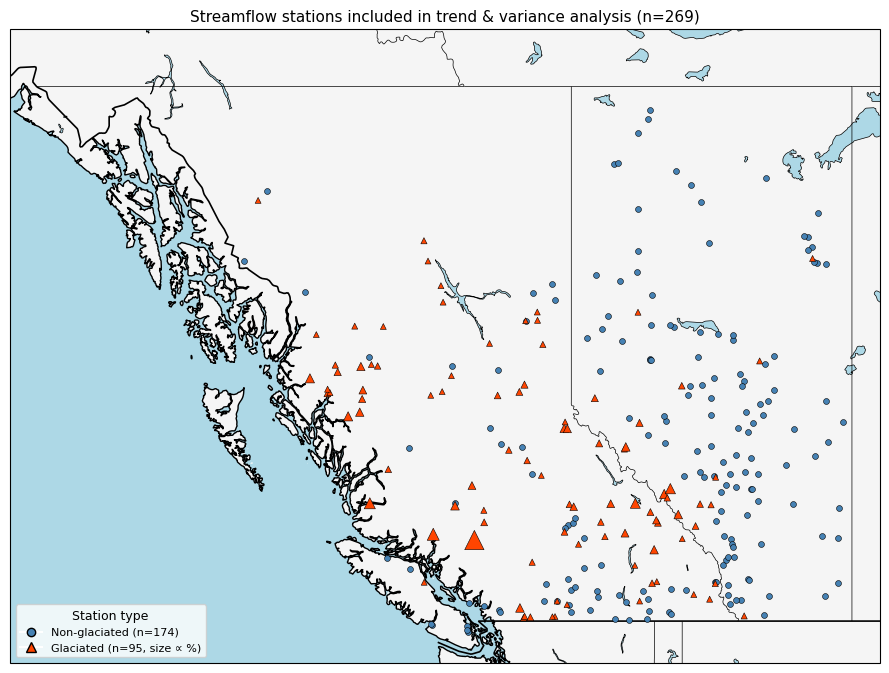

In [29]:
# Cell 2: Station inventory: count, locations, map of stations
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Determine stations included in the analysis = intersection of obs, phase_split
# predictions, and static attributes (need lat/lon).
df_static = pd.read_csv(STATIC_PATH, index_col=0)
df_static.index = df_static.index.astype(str)

df_pred_cols = pd.read_csv(PHASE_SPLIT_DIR / 'phase-split_preds_ensemble.csv', nrows=0).columns
df_obs_cols = pd.read_csv(OBS_PATH, index_col='Date', nrows=0).columns

stations = sorted(set(df_pred_cols) & set(df_obs_cols) & set(df_static.index))

df_stn = df_static.loc[stations, ['latitude', 'longitude', 'basin_area_km2', 'glacier_pct']].copy()
df_stn['glaciated'] = df_stn['glacier_pct'] > 0

# Physical glaciation classes (example thresholds per PI; exact cuts pending Tyler).
# This is the primary grouping variable for the trend / variance / clustering steps.
GLAC_CLASS_LABELS = ['Non-glaciated', 'Low (<1%)', 'Medium (1–5%)', 'High (>5%)']
df_stn['glac_class'] = pd.Categorical(
    np.select(
        [df_stn['glacier_pct'] == 0,
         df_stn['glacier_pct'] < 1,
         df_stn['glacier_pct'] <= 5],
        GLAC_CLASS_LABELS[:3],
        default=GLAC_CLASS_LABELS[3],
    ),
    categories=GLAC_CLASS_LABELS, ordered=True,
)

# WSC code prefix indicates sub-basin (05 = Nelson, 07 = Mackenzie, 08 = Pacific)
df_stn['wsc_basin'] = df_stn.index.str[:2]
basin_names = {'05': 'Nelson (AB)', '07': 'Mackenzie (BC)', '08': 'Pacific (BC)'}

print(f"Number of stations in analysis: {len(stations)}")
print(f"  Glaciated (glacier_pct > 0):   {int(df_stn['glaciated'].sum())}")
print(f"  Non-glaciated:                 {int((~df_stn['glaciated']).sum())}")
print(f"  Latitude range:  {df_stn['latitude'].min():.2f}° to {df_stn['latitude'].max():.2f}° N")
print(f"  Longitude range: {df_stn['longitude'].min():.2f}° to {df_stn['longitude'].max():.2f}° E")
print()
print("Stations by glaciation class:")
for label, n in df_stn['glac_class'].value_counts().reindex(GLAC_CLASS_LABELS).items():
    print(f"  {label:16s} n={int(n):3d}")
print()
print("Stations by WSC sub-basin:")
for code, group in df_stn.groupby('wsc_basin'):
    print(f"  {code} {basin_names.get(code, '?'):28s} n={len(group):3d}  "
          f"glaciated={int(group['glaciated'].sum()):3d}")
print()
print("Station locations (first/last rows):")
display(df_stn[['latitude', 'longitude', 'basin_area_km2', 'glacier_pct', 'glac_class']])

# Map
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())

res = '10m'
ax.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=1.2, zorder=3)

non_glac = df_stn[~df_stn['glaciated']]
glac = df_stn[df_stn['glaciated']]

ax.scatter(
    non_glac['longitude'], non_glac['latitude'],
    transform=ccrs.PlateCarree(),
    color='steelblue', s=18, marker='o', edgecolors='k', linewidths=0.4, zorder=5
)
triangle_sizes = (glac['glacier_pct'] * 3) + 18
ax.scatter(
    glac['longitude'], glac['latitude'],
    transform=ccrs.PlateCarree(),
    color='orangered', s=triangle_sizes, marker='^', edgecolors='k', linewidths=0.4, zorder=5
)

circle_marker = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='steelblue',
                              markersize=6, markeredgecolor='k', label=f'Non-glaciated (n={len(non_glac)})')
triangle_marker = mlines.Line2D([], [], color='white', marker='^', markerfacecolor='orangered',
                                markersize=7, markeredgecolor='k', label=f'Glaciated (n={len(glac)}, size ∝ %)')
ax.legend(handles=[circle_marker, triangle_marker], loc='lower left',
          title='Station type', fontsize=8, title_fontsize=9)

plt.title(f'Streamflow stations included in trend & variance analysis (n={len(stations)})', fontsize=11)
plt.tight_layout()
plt.show()

Stations per WSC drainage basin (total n=269):


,basin_name,n_stations,n_glaciated,median_area_km2,median_glacier_pct
wsc_basin,,,,,
05,Nelson (AB),68,9,448.37055,0.000000
07,Mackenzie (BC),78,17,1981.77705,0.000000
08,Pacific (BC),123,69,545.25510,0.022037


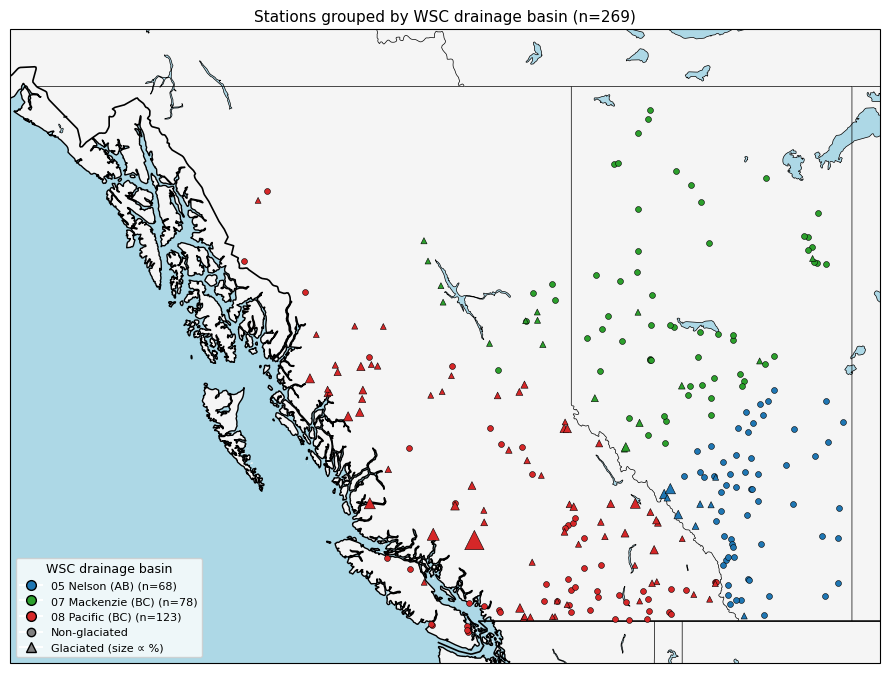

In [30]:
# Cell 3: Map grouped by WSC drainage basin (05 / 07 / 08)
basin_colors = {'05': '#1f77b4', '07': '#2ca02c', '08': '#d62728'}

# Per-basin summary
summary = df_stn.groupby('wsc_basin').agg(
    n_stations=('latitude', 'size'),
    n_glaciated=('glaciated', 'sum'),
    median_area_km2=('basin_area_km2', 'median'),
    median_glacier_pct=('glacier_pct', 'median'),
).astype({'n_glaciated': int})
summary.insert(0, 'basin_name', summary.index.map(basin_names))

print(f"Stations per WSC drainage basin (total n={len(df_stn)}):")
display(summary)

# Map
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())

res = '10m'
ax.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=1.2, zorder=3)

basin_handles = []
for code in sorted(df_stn['wsc_basin'].unique()):
    group = df_stn[df_stn['wsc_basin'] == code]
    color = basin_colors.get(code, 'gray')

    non_glac = group[~group['glaciated']]
    glac = group[group['glaciated']]

    if not non_glac.empty:
        ax.scatter(
            non_glac['longitude'], non_glac['latitude'],
            transform=ccrs.PlateCarree(),
            color=color, s=18, marker='o', edgecolors='k', linewidths=0.4, zorder=5
        )
    if not glac.empty:
        ax.scatter(
            glac['longitude'], glac['latitude'],
            transform=ccrs.PlateCarree(),
            color=color, s=(glac['glacier_pct'] * 3) + 18,
            marker='^', edgecolors='k', linewidths=0.4, zorder=5
        )

    basin_handles.append(
        mlines.Line2D([], [], color='white', marker='o', markerfacecolor=color,
                      markersize=7, markeredgecolor='k',
                      label=f"{code} {basin_names.get(code, '?')} (n={len(group)})")
    )

shape_handles = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray',
                  markersize=6, markeredgecolor='k', label='Non-glaciated'),
    mlines.Line2D([], [], color='white', marker='^', markerfacecolor='gray',
                  markersize=7, markeredgecolor='k', label='Glaciated (size ∝ %)'),
]

ax.legend(handles=basin_handles + shape_handles, loc='lower left',
          title='WSC drainage basin', fontsize=8, title_fontsize=9)
plt.title(f'Stations grouped by WSC drainage basin (n={len(df_stn)})', fontsize=11)
plt.tight_layout()
plt.show()

<a id="feature-maps"></a>
## 2. Feature Maps

Static basin attributes mapped in space, to check for spatial structure before the station-level analysis.

- **Mean elevation** — quartile classes (no principled physical threshold yet; quartiles are a fallback).
- **Glaciation class** — physical thresholds (PI's example, pending Tyler): Non-glaciated / Low `<1%` / Medium `1–5%` / High `>5%`. This is the primary grouping variable for the trend, variance, and clustering steps.
- **Basin area (km²)** — continuous, log-scaled (spans several orders of magnitude).

Elevation quartiles (mean_elev, m):
                   n       min_m       max_m
elev_q                                      
Q1 (209–830 m)    68   208.91566   830.47705
Q2 (830–1233 m)   67   834.20245  1232.82100
Q3 (1233–1546 m)  67  1246.17330  1546.10820
Q4 (1546–2433 m)  67  1546.16670  2433.07420


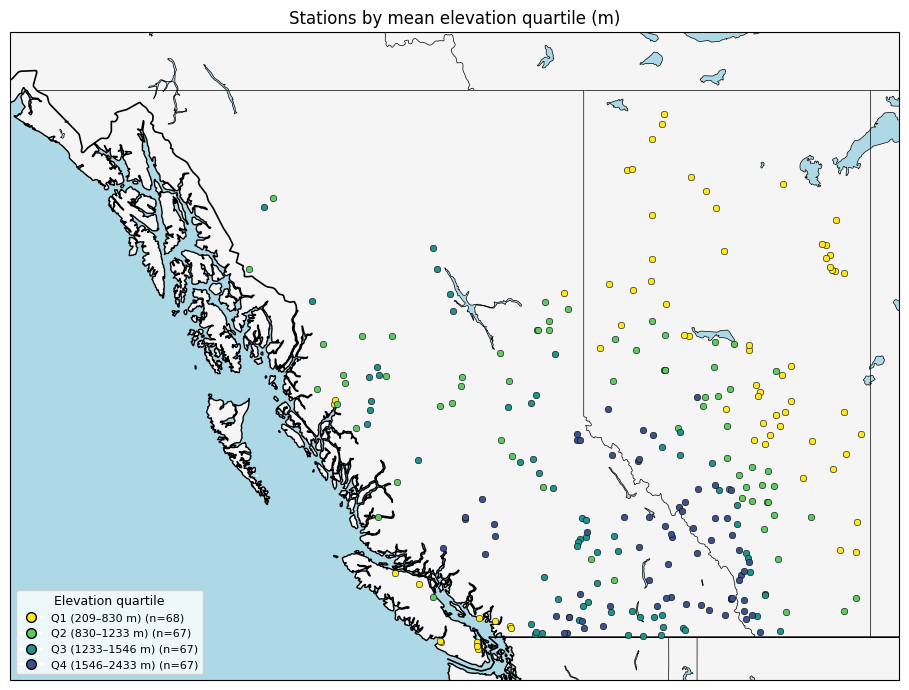


Stations by glaciation class:
                 n   min_pct    max_pct
glac_class                             
Non-glaciated  174  0.000000   0.000000
Low (<1%)       44  0.000211   0.843885
Medium (1–5%)   34  1.098193   4.793836
High (>5%)      17  5.709784  58.519697


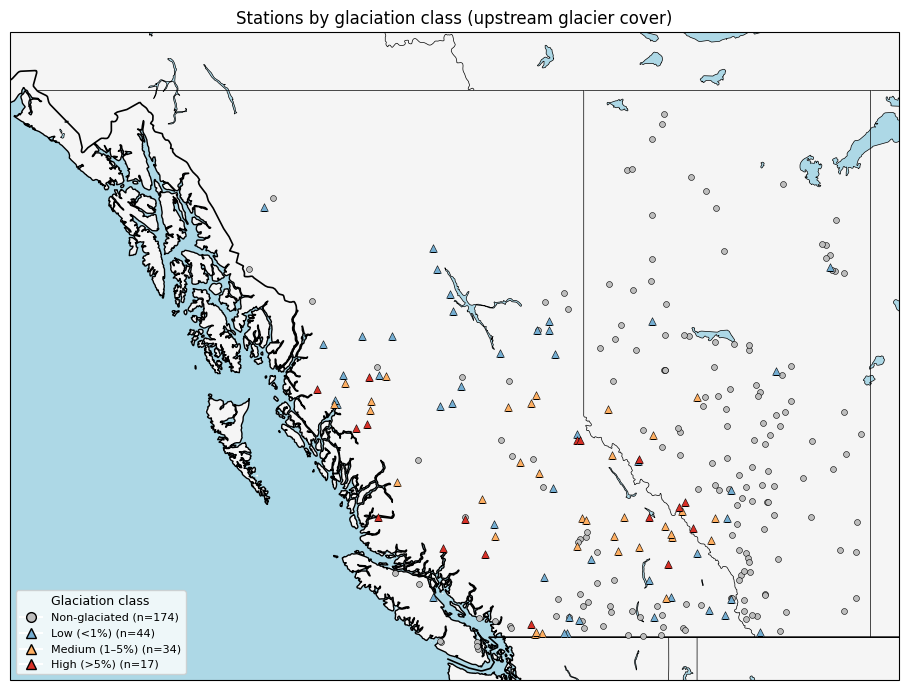


Basin area: min=2.9 km², median=762.3 km², max=132572 km²


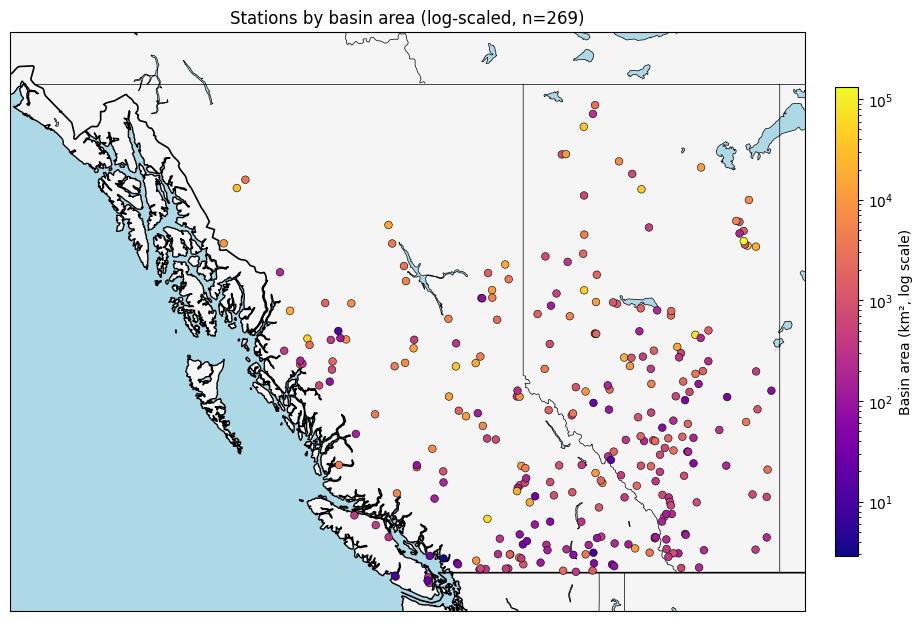

In [31]:
# Cell 4: Static-attribute maps — elevation (quartiles), glaciation class, basin area
from matplotlib.colors import LogNorm

# Pull mean_elev into df_stn (basin_area_km2, glacier_pct, glac_class already present)
df_stn['mean_elev'] = df_static.loc[df_stn.index, 'mean_elev']

quartile_colors = {0: '#fde725', 1: '#5ec962', 2: '#21918c', 3: '#3b528b'}  # viridis-like

def draw_base(ax):
    ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())
    res = '10m'
    ax.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue',
                   edgecolor='black', linewidth=0.5, zorder=2)
    provs = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines',
        scale=res, facecolor='none'
    )
    ax.add_feature(provs, edgecolor='black', linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black',
                   linewidth=1.2, zorder=3)

# =========================================================
# Map 1: Mean elevation — quartiles (categorical)
# =========================================================
elev_quartiles, elev_bins = pd.qcut(
    df_stn['mean_elev'], q=4, retbins=True, labels=False, duplicates='drop'
)
df_stn['elev_q'] = elev_quartiles.astype(int)

elev_labels = {i: f"Q{i+1} ({elev_bins[i]:.0f}–{elev_bins[i+1]:.0f} m)" for i in range(4)}
print("Elevation quartiles (mean_elev, m):")
print(df_stn.groupby('elev_q').agg(
    n=('mean_elev', 'size'),
    min_m=('mean_elev', 'min'),
    max_m=('mean_elev', 'max'),
).rename(index=elev_labels))

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.Mercator())
draw_base(ax)

handles = []
for q in range(4):
    grp = df_stn[df_stn['elev_q'] == q]
    ax.scatter(
        grp['longitude'], grp['latitude'],
        transform=ccrs.PlateCarree(),
        color=quartile_colors[q], s=22, marker='o',
        edgecolors='k', linewidths=0.4, zorder=5
    )
    handles.append(mlines.Line2D(
        [], [], color='white', marker='o', markerfacecolor=quartile_colors[q],
        markersize=7, markeredgecolor='k', label=f"{elev_labels[q]} (n={len(grp)})"
    ))
ax.legend(handles=handles, loc='lower left',
          title='Elevation quartile', fontsize=8, title_fontsize=9)
plt.title("Stations by mean elevation quartile (m)", fontsize=12)
plt.tight_layout()
plt.show()

# =========================================================
# Map 2: Glaciation class — physical thresholds (PI; pending Tyler)
#        Non-glaciated / Low <1% / Medium 1–5% / High >5%
# =========================================================
glac_class_colors = {
    'Non-glaciated': '#bdbdbd',   # gray
    'Low (<1%)':     '#74add1',   # light blue
    'Medium (1–5%)': '#fdae61',   # orange
    'High (>5%)':    '#d73027',   # red
}
glac_class_markers = {
    'Non-glaciated': 'o',
    'Low (<1%)':     '^',
    'Medium (1–5%)': '^',
    'High (>5%)':    '^',
}

print("\nStations by glaciation class:")
print(df_stn.groupby('glac_class', observed=False).agg(
    n=('glacier_pct', 'size'),
    min_pct=('glacier_pct', 'min'),
    max_pct=('glacier_pct', 'max'),
))

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.Mercator())
draw_base(ax)

handles = []
for label in GLAC_CLASS_LABELS:
    grp = df_stn[df_stn['glac_class'] == label]
    if grp.empty:
        continue
    marker = glac_class_markers[label]
    ax.scatter(
        grp['longitude'], grp['latitude'],
        transform=ccrs.PlateCarree(),
        color=glac_class_colors[label],
        s=18 if marker == 'o' else 30, marker=marker,
        edgecolors='k', linewidths=0.4,
        zorder=4 if label == 'Non-glaciated' else 5,
    )
    handles.append(mlines.Line2D(
        [], [], color='white', marker=marker, markerfacecolor=glac_class_colors[label],
        markersize=7, markeredgecolor='k', label=f"{label} (n={len(grp)})"
    ))
ax.legend(handles=handles, loc='lower left',
          title='Glaciation class', fontsize=8, title_fontsize=9)
plt.title("Stations by glaciation class (upstream glacier cover)", fontsize=12)
plt.tight_layout()
plt.show()

# =========================================================
# Map 3: Basin area — continuous, log-scaled (spans orders of magnitude)
# =========================================================
print(f"\nBasin area: min={df_stn['basin_area_km2'].min():.1f} km², "
      f"median={df_stn['basin_area_km2'].median():.1f} km², "
      f"max={df_stn['basin_area_km2'].max():.0f} km²")

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.Mercator())
draw_base(ax)

sc = ax.scatter(
    df_stn['longitude'], df_stn['latitude'],
    transform=ccrs.PlateCarree(),
    c=df_stn['basin_area_km2'], cmap='plasma',
    norm=LogNorm(vmin=df_stn['basin_area_km2'].min(),
                 vmax=df_stn['basin_area_km2'].max()),
    s=30, marker='o', edgecolors='k', linewidths=0.4, zorder=5
)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label('Basin area (km², log scale)', fontsize=10)

plt.title(f"Stations by basin area (log-scaled, n={len(df_stn)})", fontsize=12)
plt.tight_layout()
plt.show()

<a id="feature-distributions"></a>
## 3. Feature Distributions

Non-spatial view of the same attributes: histograms with **mean** (red dashed) and **median** (black dotted) markers. Highlights the skew (basin area, glacier cover) that motivates the log scaling and the separate handling of 0%-glacier stations above.

Summary statistics:
                count         mean      median           std        min  \
mean_elev       269.0  1217.584241  1232.82100    469.889799  208.91566   
basin_area_km2  269.0  4212.492548   762.28020  11682.741019    2.90070   
glacier_pct     269.0     1.100260     0.00000      4.255718    0.00000   
latitude        269.0    52.733050    52.51738      2.645689   48.72783   

                          max  
mean_elev         2433.074200  
basin_area_km2  132571.586700  
glacier_pct         58.519697  
latitude            59.580800  


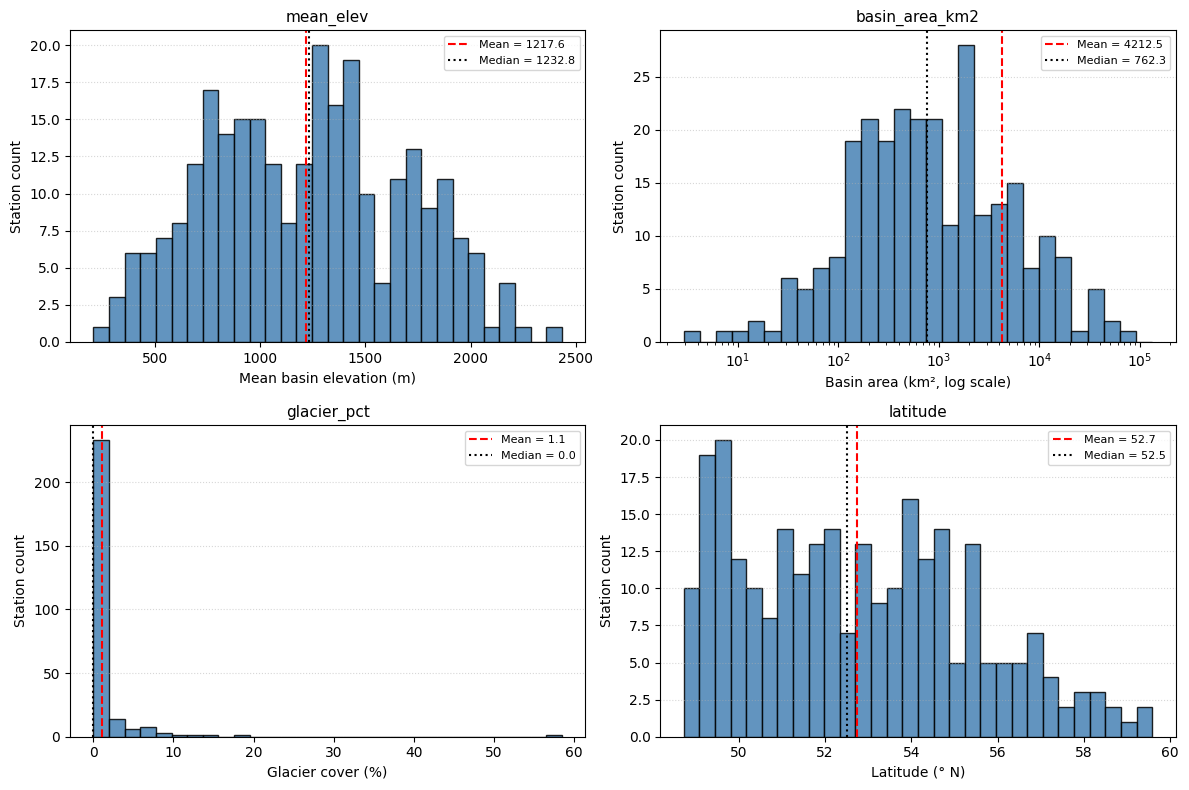

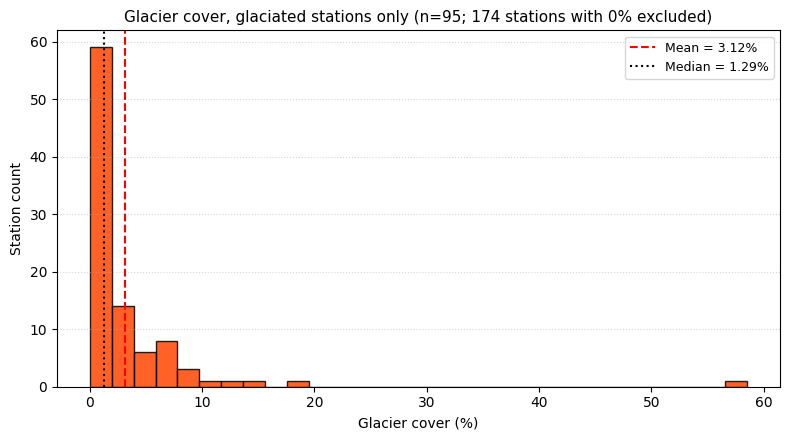

In [32]:
# Cell 5: Non-spatial feature exploration — distribution histograms with mean/median
# Distributions of the static attributes used to characterise basins.
# basin_area_km2 is log-scaled (heavy right tail); glacier_pct keeps a 0% spike.

features = [
    ('mean_elev',       'Mean basin elevation (m)',        'linear', None),
    ('basin_area_km2',  'Basin area (km², log scale)',     'log',    None),
    ('glacier_pct',     'Glacier cover (%)',               'linear', None),
    ('latitude',        'Latitude (° N)',                  'linear', None),
]

print("Summary statistics:")
print(df_stn[[f[0] for f in features]].describe().T[['count', 'mean', '50%', 'std', 'min', 'max']]
      .rename(columns={'50%': 'median'}))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label, xscale, _) in zip(axes, features):
    values = df_stn[col].dropna()

    if xscale == 'log':
        # Log-spaced bins; values must be positive
        positive = values[values > 0]
        bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 30)
        ax.hist(positive, bins=bins, color='steelblue', edgecolor='k', alpha=0.85)
        ax.set_xscale('log')
        mean_val, median_val = positive.mean(), positive.median()
    else:
        ax.hist(values, bins=30, color='steelblue', edgecolor='k', alpha=0.85)
        mean_val, median_val = values.mean(), values.median()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {mean_val:.1f}')
    ax.axvline(median_val, color='black', linestyle=':', linewidth=1.5,
               label=f'Median = {median_val:.1f}')

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Station count', fontsize=10)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Glacier-% has a strong 0-spike; show the conditional distribution over glaciated stations only
glac_pos = df_stn.loc[df_stn['glacier_pct'] > 0, 'glacier_pct']
n_zero = int((df_stn['glacier_pct'] == 0).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(glac_pos, bins=30, color='orangered', edgecolor='k', alpha=0.85)
ax.axvline(glac_pos.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {glac_pos.mean():.2f}%')
ax.axvline(glac_pos.median(), color='black', linestyle=':', linewidth=1.5,
           label=f'Median = {glac_pos.median():.2f}%')
ax.set_xlabel('Glacier cover (%)', fontsize=10)
ax.set_ylabel('Station count', fontsize=10)
ax.set_title(f'Glacier cover, glaciated stations only '
             f'(n={len(glac_pos)}; {n_zero} stations with 0% excluded)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

<a id="station-analysis"></a>

## 4. Station Analysis

For each station, on August **monthly** flow (mean or total, TBD):

- Time series plot with fitted trend (visual inspection is the primary deliverable, not the trend statistic)
- Moving variance with ≥10-yr window
- Grouped output by glaciation class

**Note:** "a single linear trend is not appropriate" if oscillatory patterns exist. Visual inspection of each station is required before any trend statistic is reported. If a station shows non-linear behavior, note it descriptively rather than fitting a linear trend regardless.

August mean flow matrix: 43 years (1980–2022) × 269 stations
Station-years masked (<20 valid Aug days): 18 of 11567

Completeness (out of 43 years):
  full record:     254 stations
  >= 35 years:     269 stations
  <  35 years:     0 stations


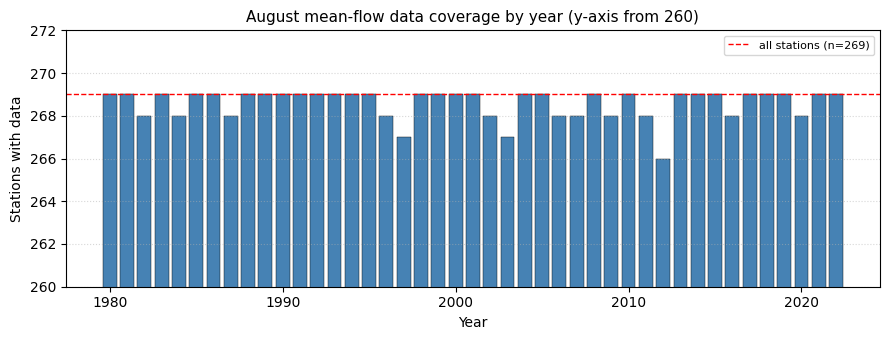

,05AA004,05AA008,05AA022,05AA027,05AA028,05AB005,05AB029,05AD003
year,,,,,,,,
1980,0.366613,2.473871,4.820968,0.763065,3.255484,0.086742,0.000000,7.730323
1981,0.369903,4.206129,6.737742,1.071742,4.664194,0.870484,0.049387,10.162258
1982,0.087613,3.013226,5.895161,0.769613,4.333226,0.126871,0.000000,11.521935
1983,0.059774,2.791290,6.279032,0.761032,4.313226,0.002548,0.000000,9.875161
1984,0.070903,2.732581,4.343871,0.609806,3.005484,0.000000,0.000000,7.946774


In [33]:
# Cell 6: August mean flow (observed) — the input series for Step 2
# PI default: August MEAN of daily observed streamflow, one value per station-year, 1980–2022.
# (Total August flow is also acceptable per PI; switch AGG below if that's decided.)

AUG_MONTH = 8
AGG = 'mean'        # 'mean' (PI default) or 'sum' for total August flow
MIN_AUG_DAYS = 20   # require >= this many valid daily obs in an August, else mask that station-year

obs_daily = pd.read_csv(OBS_PATH, index_col='Date', parse_dates=True)[stations]
aug = obs_daily[obs_daily.index.month == AUG_MONTH]

grp = aug.groupby(aug.index.year)
aug_days = grp.count()                                   # valid daily obs per station-year
aug_flow = grp.mean() if AGG == 'mean' else grp.sum()    # August mean (or total) daily flow, m³/s
aug_flow = aug_flow.where(aug_days >= MIN_AUG_DAYS)       # drop sparsely-observed station-years
aug_flow.index.name = 'year'

n_years, n_stn = aug_flow.shape
print(f"August {AGG} flow matrix: {n_years} years "
      f"({aug_flow.index.min()}–{aug_flow.index.max()}) × {n_stn} stations")
print(f"Station-years masked (<{MIN_AUG_DAYS} valid Aug days): "
      f"{int((aug_days < MIN_AUG_DAYS).sum().sum())} of {aug_days.size}")

# Per-station record completeness
years_present = aug_flow.notna().sum()
print(f"\nCompleteness (out of {n_years} years):")
print(f"  full record:     {int((years_present == n_years).sum())} stations")
print(f"  >= 35 years:     {int((years_present >= 35).sum())} stations")
print(f"  <  35 years:     {int((years_present <  35).sum())} stations")

# Coverage over time: how many stations have an August value each year.
# Coverage stays high (260+), so zoom the y-axis to 260+ to resolve year-to-year variation.
coverage = aug_flow.notna().sum(axis=1)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(aug_flow.index, coverage, color='steelblue', edgecolor='k', linewidth=0.3)
ax.axhline(n_stn, color='red', linestyle='--', linewidth=1, label=f'all stations (n={n_stn})')
ax.set_ylim(260, n_stn + 3)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Stations with data', fontsize=10)
ax.set_title(f'August {AGG}-flow data coverage by year (y-axis from 260)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

display(aug_flow.iloc[:, :8].head())

The dataset comprises 43 years (1980–2022) × 269 stations = 11,567 station-years. After masking station-years with fewer than 20 valid August days, 11,549 station-years remain (99.84% complete). Per-station completeness: 254 stations (94%) have full 43-year records; all 269 stations have at least 35 years. No structural coverage issues require sample-size adjustment for downstream analysis.

### Per Station Streamflow

Robust (non-parametric) trend line per station on August mean flow. 

Reported as a **slope only**: no p-values, confidence intervals, or significance testing. 

Raw slope is in m³/s per year; because that scales with basin size, a **relative slope** (%/yr of the station's median August flow) is added so stations are comparable. 

Note: inspect each series — a single straight line may not describe oscillatory records well.

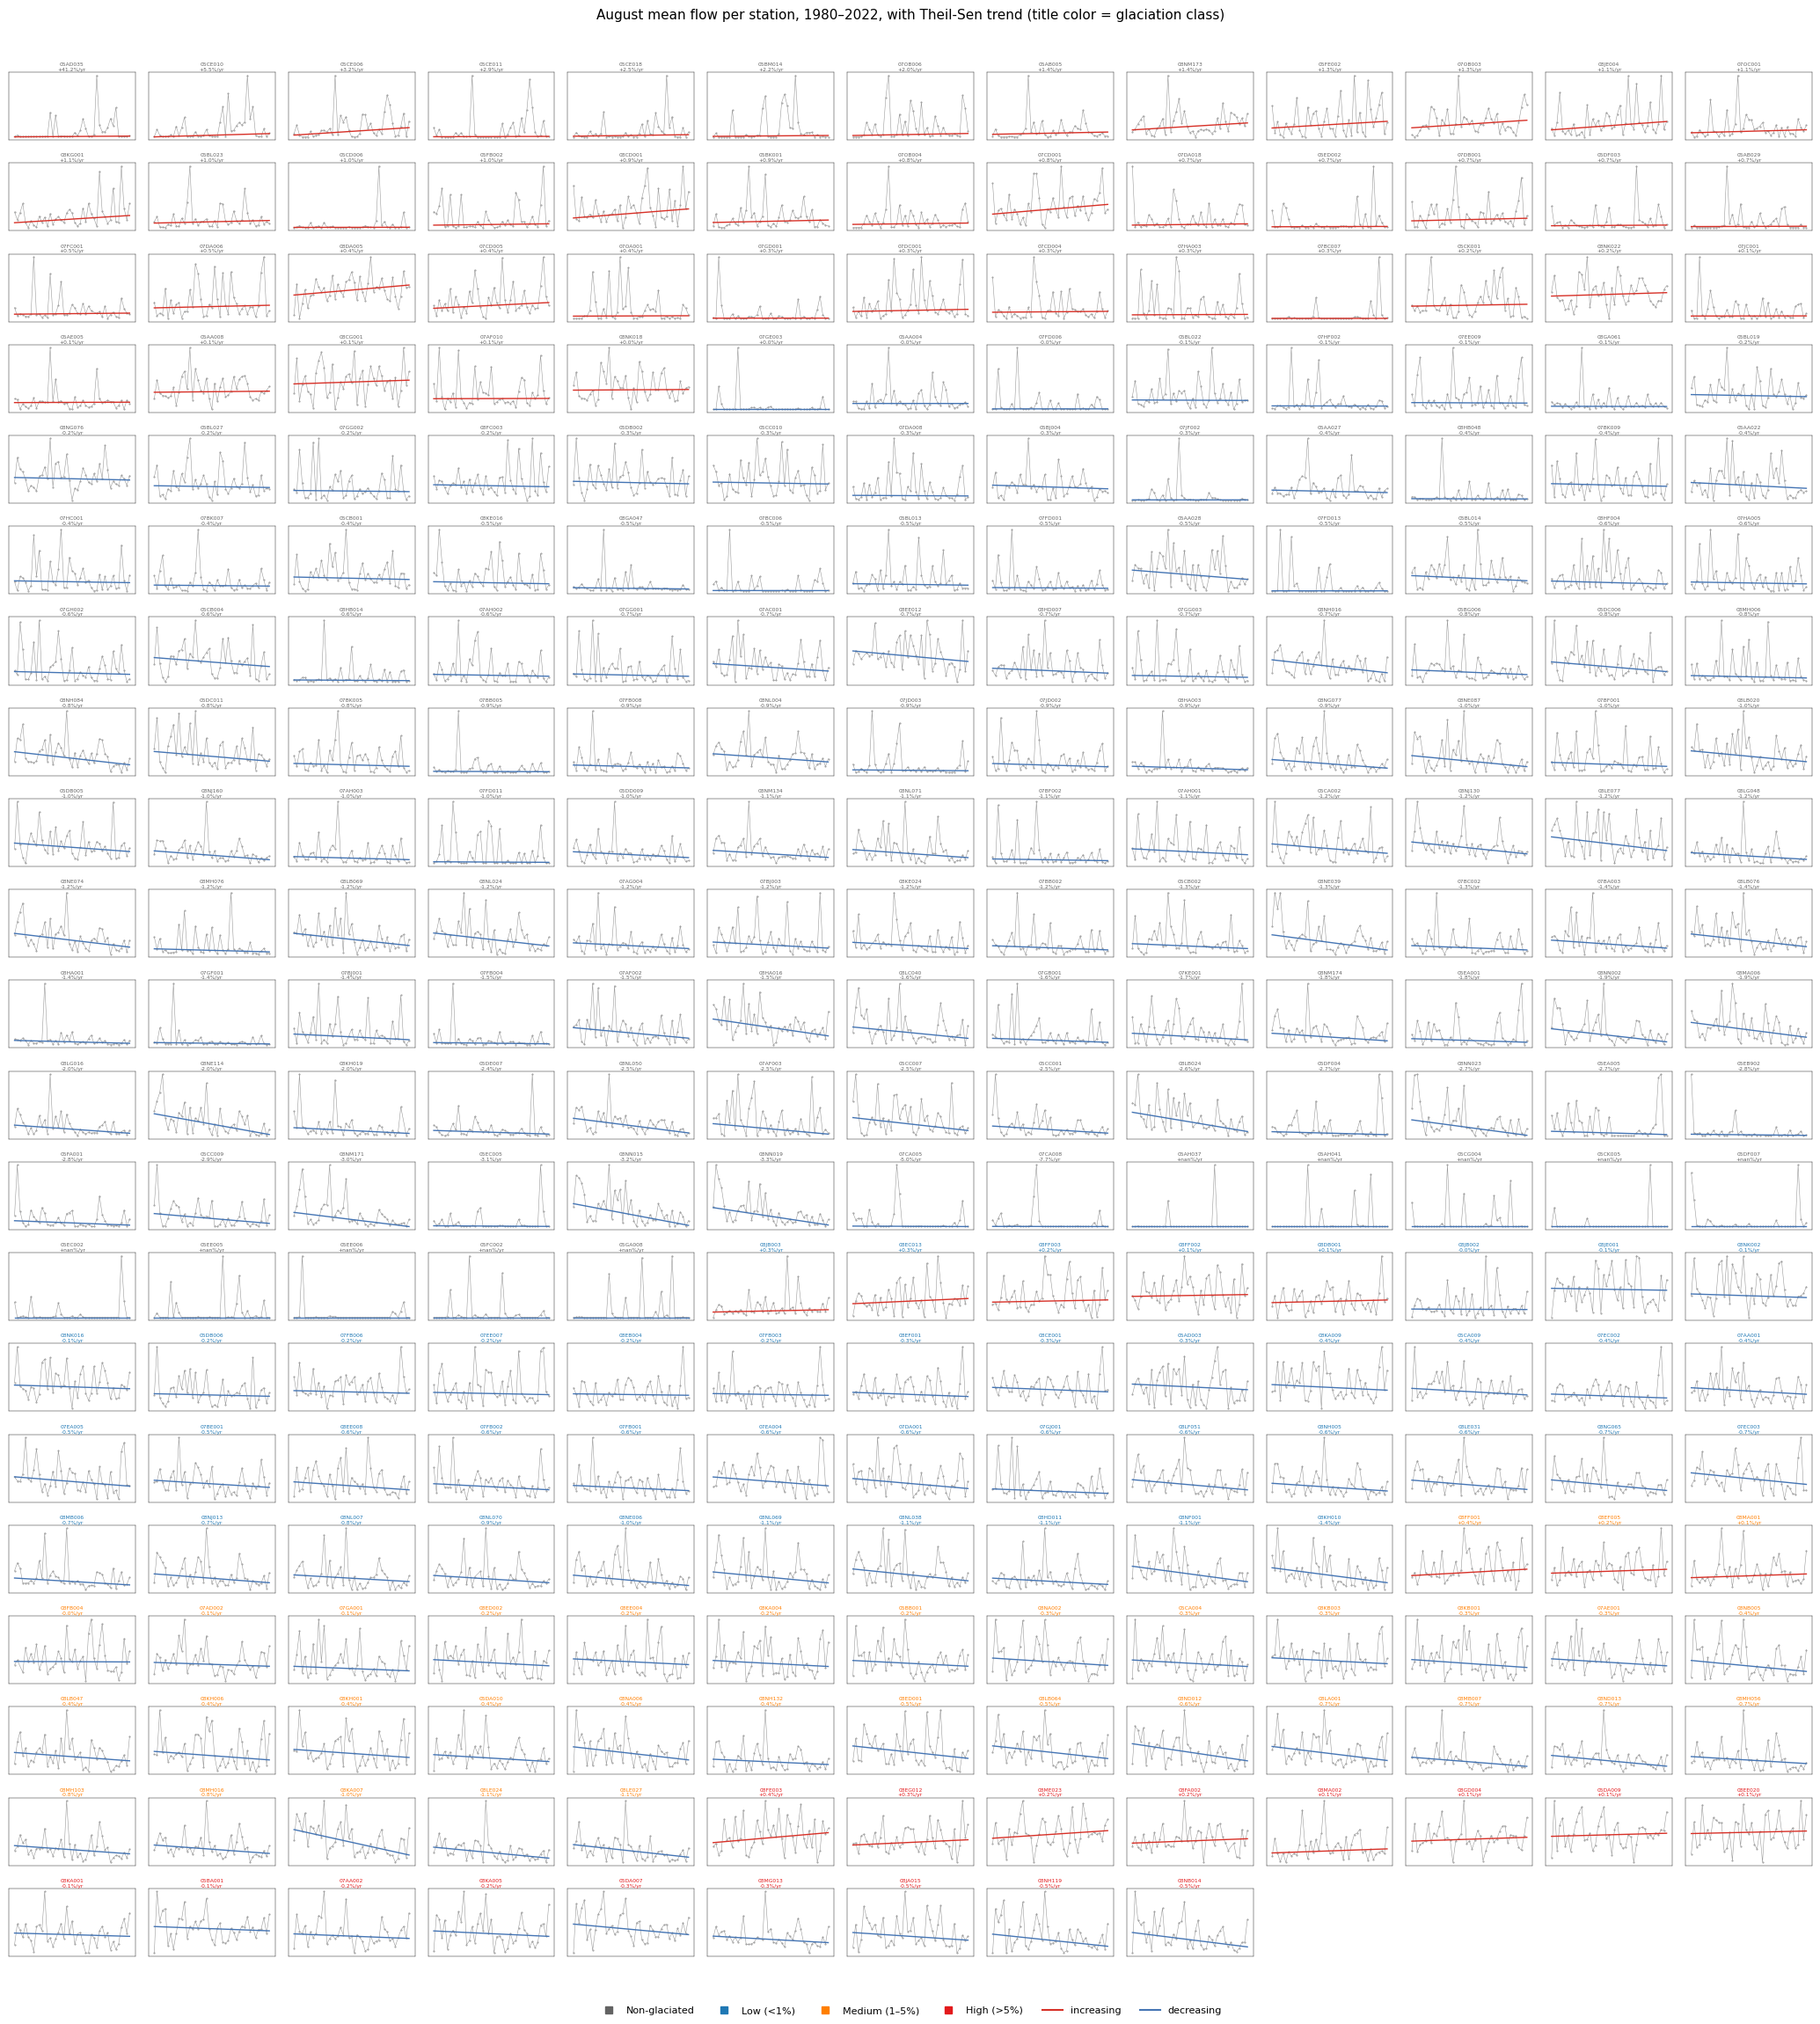

Theil-Sen slope reported for 269 / 269 stations (>= 10 years).


,glac_class,wsc_basin,n_years,median_Q,slope_m3s_per_yr,rel_slope_pct_per_yr
05AD035,Non-glaciated,05,43.0,0.000,0.0001,41.20
05CE010,Non-glaciated,05,43.0,0.005,0.0003,5.47
05CE006,Non-glaciated,05,43.0,0.045,0.0015,3.23
05CE011,Non-glaciated,05,43.0,0.000,0.0000,2.87
05CE018,Non-glaciated,05,43.0,0.013,0.0003,2.53
...,...,...,...,...,...,...
05EC002,Non-glaciated,05,43.0,0.000,0.0000,NaN
05EE005,Non-glaciated,05,43.0,0.000,0.0000,NaN
05EE006,Non-glaciated,05,43.0,0.000,0.0000,NaN
05FC002,Non-glaciated,05,43.0,0.000,0.0000,NaN



Theil-Sen slope statistics (median is robust; mean/max sensitive to small-median outliers):


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/4227882496.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slope_stats = df_slopes.groupby('glac_class', observed=False).apply(slope_summary)


,n,median_slope_m3s_yr,median_rel_pct_yr,mean_rel_pct_yr,pct_increasing,min_rel_pct_yr,max_rel_pct_yr
glac_class,,,,,,,
Non-glaciated,174.0,-0.003,-0.651,-0.389,25.287,-7.692,41.204
Low (<1%),44.0,-0.059,-0.478,-0.459,11.364,-1.420,0.334
Medium (1–5%),34.0,-0.274,-0.369,-0.406,8.824,-1.119,0.382
High (>5%),17.0,-0.027,-0.126,-0.077,47.059,-0.549,0.384
All,269.0,-0.012,-0.493,-0.382,22.305,-7.692,41.204


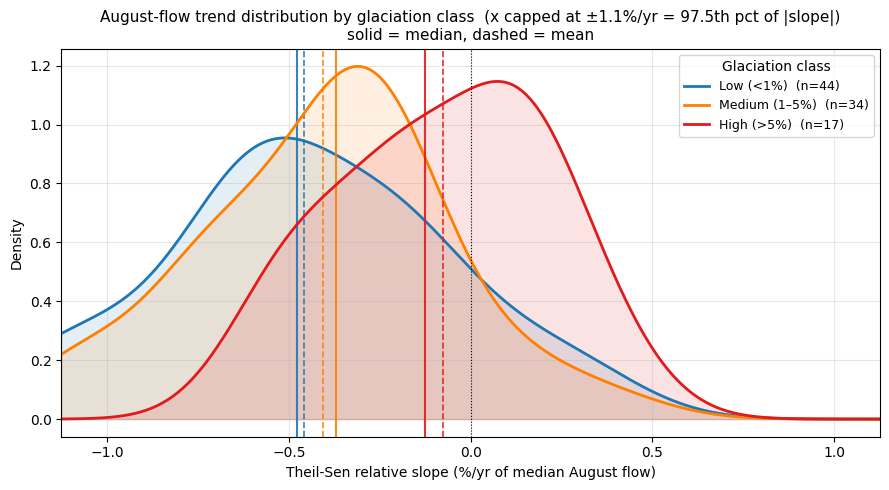

In [47]:
# Cell 7: Theil-Sen trend per station on August mean flow (descriptive trendline)
from scipy.stats import theilslopes

MIN_YEARS = 10  # minimum record length to fit a slope

# --- Per-station Theil-Sen slope + intercept ---
recs = {}
for stn in aug_flow.columns:
    s = aug_flow[stn].dropna()
    if len(s) < MIN_YEARS:
        recs[stn] = (np.nan, np.nan, len(s))
        continue
    r = theilslopes(s.values, s.index.values.astype(float))
    recs[stn] = (r.slope, r.intercept, len(s))

df_slopes = pd.DataFrame(recs, index=['slope_m3s_per_yr', 'intercept', 'n_years']).T
df_slopes['median_Q'] = aug_flow.median()
df_slopes['rel_slope_pct_per_yr'] = np.where(
    df_slopes['median_Q'] > 0,
    100 * df_slopes['slope_m3s_per_yr'] / df_slopes['median_Q'],
    np.nan,
)
df_slopes['glac_class'] = df_stn['glac_class']
df_slopes['wsc_basin'] = df_stn['wsc_basin']

# --- Small-multiples grid: every station, series (gray) + Theil-Sen line ---
# Title color = glaciation class; line color = trend direction; annotation = relative slope.
class_color = {
    'Non-glaciated': '#636363',
    'Low (<1%)':     '#1f78b4',
    'Medium (1–5%)': '#ff7f00',
    'High (>5%)':    '#e31a1c',
}
order = df_slopes.sort_values(['glac_class', 'rel_slope_pct_per_yr'],
                              ascending=[True, False]).index

ncols = 13
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 1.1))
axes = axes.flatten()

for ax, stn in zip(axes, order):
    s = aug_flow[stn].dropna()
    ax.plot(s.index, s.values, color='0.6', lw=0.4, marker='.', ms=1)
    slope, intc = df_slopes.at[stn, 'slope_m3s_per_yr'], df_slopes.at[stn, 'intercept']
    xx = np.array([s.index.min(), s.index.max()], dtype=float)
    ax.plot(xx, intc + slope * xx, color='#d73027' if slope > 0 else '#4575b4', lw=1.0)
    ax.set_title(f"{stn}\n{df_slopes.at[stn, 'rel_slope_pct_per_yr']:+.1f}%/yr",
                 fontsize=4.3, pad=1,
                 color=class_color[str(df_slopes.at[stn, 'glac_class'])])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.3)
for ax in axes[len(order):]:
    ax.axis('off')

class_handles = [mlines.Line2D([], [], color=c, marker='s', ls='', ms=6, label=l)
                 for l, c in class_color.items()]
trend_handles = [mlines.Line2D([], [], color='#d73027', lw=1.5, label='increasing'),
                 mlines.Line2D([], [], color='#4575b4', lw=1.5, label='decreasing')]
fig.tight_layout(rect=[0, 0.025, 1, 0.97])
fig.suptitle('August mean flow per station, 1980–2022, with Theil-Sen trend '
             '(title color = glaciation class)', fontsize=11, y=0.99)
fig.legend(handles=class_handles + trend_handles, loc='lower center',
           ncol=6, fontsize=8, frameon=False)
plt.show()

# --- Per-station slopes (sorted, most increasing first) ---
n_fit = int(df_slopes['slope_m3s_per_yr'].notna().sum())
print(f"Theil-Sen slope reported for {n_fit} / {len(df_slopes)} stations "
      f"(>= {MIN_YEARS} years).")
display(
    df_slopes.sort_values('rel_slope_pct_per_yr', ascending=False)[
        ['glac_class', 'wsc_basin', 'n_years', 'median_Q',
         'slope_m3s_per_yr', 'rel_slope_pct_per_yr']
    ].round({'median_Q': 3, 'slope_m3s_per_yr': 4, 'rel_slope_pct_per_yr': 2})
)

# --- Summary statistics of the slopes, by glaciation class (+ All) ---
def slope_summary(g):
    sl, rel = g['slope_m3s_per_yr'], g['rel_slope_pct_per_yr']
    return pd.Series({
        'n': int(sl.notna().sum()),
        'median_slope_m3s_yr': sl.median(),
        'median_rel_pct_yr': rel.median(),
        'mean_rel_pct_yr': rel.mean(),
        'pct_increasing': 100 * (sl > 0).mean(),
        'min_rel_pct_yr': rel.min(),
        'max_rel_pct_yr': rel.max(),
    })

slope_stats = df_slopes.groupby('glac_class', observed=False).apply(slope_summary)
slope_stats.loc['All'] = slope_summary(df_slopes)
print("\nTheil-Sen slope statistics (median is robust; mean/max sensitive to small-median outliers):")
display(slope_stats.round(3))


# --- Distribution of relative trend by glaciation class (Low / Medium / High) ---
# Chosen plot: overlaid KDEs. Three stacked histograms muddy each other; KDE curves
# most clearly show whether the class distributions sit apart (i.e. are "identifiable").
# Purely descriptive — visual separability is NOT a significance test (deferred phase).
# Symmetric x about 0, capped at the 97.5th pct of |rel_slope| (cf. the trend-map cap).
from scipy.stats import gaussian_kde

glac_classes = GLAC_CLASS_LABELS[1:]   # Low (<1%), Medium (1-5%), High (>5%)
dist = {c: df_slopes.loc[df_slopes['glac_class'] == c, 'rel_slope_pct_per_yr'].dropna().values
        for c in glac_classes}

pooled = np.concatenate([v for v in dist.values() if len(v)])
L = float(np.nanpercentile(np.abs(pooled), 97.5))   # symmetric cap, like the geographic plot
xx = np.linspace(-L, L, 400)

fig, ax = plt.subplots(figsize=(9, 5))
for c in glac_classes:
    v = dist[c]
    if len(v) < 2:
        continue
    kde = gaussian_kde(v)
    col = class_color[c]
    ax.plot(xx, kde(xx), color=col, lw=2, label=f"{c}  (n={len(v)})")
    ax.fill_between(xx, kde(xx), color=col, alpha=0.12)
    ax.axvline(np.median(v), color=col, lw=1.5, ls='-',  alpha=0.9)   # solid = median
    ax.axvline(np.mean(v),   color=col, lw=1.2, ls='--', alpha=0.9)   # dashed = mean

ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlim(-L, L)
ax.set_xlabel('Theil-Sen relative slope (%/yr of median August flow)')
ax.set_ylabel('Density')
ax.set_title(f'August-flow trend distribution by glaciation class  '
             f'(x capped at ±{L:.1f}%/yr = 97.5th pct of |slope|)\n'
             'solid = median, dashed = mean', fontsize=11)
ax.legend(fontsize=9, title='Glaciation class')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<a id="trend-inference"></a>
### Cell 7b — Inference: is the relative trend < 0, by glaciation class?

**First inferential step in EXP4a** (deferred list — see `methods.md`, 2026-06-03). The Cell 7 distributions show the glaciated classes sitting below 0; this formalizes "is the per-class location of the relative Theil-Sen slope `< 0`?" The motivation: individual records are noisy / non-linear, but Theil-Sen is robust, so the decrease should be identifiable at the **class** level even where single stations are not. Run for all four classes — **Non-glaciated is the expected-null contrast** (the trend map showed it does not support a decrease).

**Read the p-values as directional, not calibrated:** stations are spatially autocorrelated, so effective n < n and the tests are anti-conservative. Wilcoxon (assumes symmetry) is paired with a sign test (median only) and a bootstrap median CI so no single number is load-bearing.

In [48]:
# Cell 7b: one-sample inference on per-station relative Theil-Sen slopes vs 0, by glaciation class
# ------------------------------------------------------------------------------------------------
# STEP CHANGE: first inferential cell in EXP4a (deferred list per CLAUDE.md; logged 2026-06-03).
# H1: within a glaciation class, the per-station relative slopes are DECREASING (location < 0).
#
# CAVEATS (read before quoting any p-value):
#  - Stations are spatially autocorrelated -> effective n < n; p-values & bootstrap CI are
#    anti-conservative (too tight). Treat as DIRECTIONAL, not calibrated. Honest fix =
#    regional / spatial-block resampling (not implemented here).
#  - Wilcoxon signed-rank assumes symmetry about the median; slope dists may be skewed, so the
#    sign test (median only, no symmetry assumption) is reported alongside as a robustness check.
#  - 4 classes tested -> multiple comparisons; raw p-values, no correction.
#  - n small per class -> exact p where scipy allows; large-n classes fall back to normal approx.
from scipy.stats import wilcoxon, binomtest

BOOT = 10000
_rng = np.random.default_rng(42)

def boot_median_ci(v, n_boot=BOOT, rng=_rng):
    idx = rng.integers(0, len(v), size=(n_boot, len(v)))
    meds = np.median(v[idx], axis=1)
    return np.percentile(meds, [2.5, 97.5])

rows = []
for c in GLAC_CLASS_LABELS:
    v = df_slopes.loc[df_slopes['glac_class'] == c, 'rel_slope_pct_per_yr'].dropna().values
    if len(v) < 3:
        rows.append({'class': c, 'n': len(v)})
        continue
    n = len(v)
    k_dec = int((v < 0).sum())
    w = wilcoxon(v, alternative='less')                       # location < 0 ?
    sgn = binomtest(k_dec, n, 0.5, alternative='greater')     # >half decreasing ?
    lo, hi = boot_median_ci(v)
    rows.append({
        'class': c, 'n': n,
        'median_pct_yr': float(np.median(v)),
        'med_CI_lo': lo, 'med_CI_hi': hi,
        'frac_decr': k_dec / n,
        'wilcoxon_p_lt0': w.pvalue,
        'sign_p_lt0': sgn.pvalue,
    })

infer = pd.DataFrame(rows).set_index('class')
print("One-sample location vs 0 on per-station relative Theil-Sen slope (%/yr), by glaciation class")
print("H1: DECREASING (location < 0).  p one-sided, RAW.  median CI = percentile bootstrap (B=%d)." % BOOT)
print("NOTE: spatial autocorrelation -> p-values anti-conservative; directional only.\n")
print(infer.to_string(float_format=lambda x: f'{x:.4g}'))

One-sample location vs 0 on per-station relative Theil-Sen slope (%/yr), by glaciation class
H1: DECREASING (location < 0).  p one-sided, RAW.  median CI = percentile bootstrap (B=10000).
NOTE: spatial autocorrelation -> p-values anti-conservative; directional only.

                 n  median_pct_yr  med_CI_lo  med_CI_hi  frac_decr  wilcoxon_p_lt0  sign_p_lt0
class                                                                                         
Non-glaciated  164        -0.6509    -0.8638    -0.4837     0.7256       1.093e-09   3.339e-09
Low (<1%)       44        -0.4778    -0.5958    -0.2964     0.8864       2.026e-09   7.026e-08
Medium (1–5%)   34        -0.3694    -0.5195     -0.256     0.9118       5.262e-08    3.83e-07
High (>5%)      17        -0.1261    -0.2869     0.1288     0.5294          0.1764         0.5


<a id="trend-vs-glacier"></a>
### Cell 7c — Relative trend vs glacier cover (scatter)

Plain descriptive scatter behind the 7b table: per-station relative Theil-Sen slope vs glacier cover (%), colored by class, with each class median marked (diamond). No smoother, no added test — just the raw gradient. Read it for whether the decrease attenuates as glacier cover rises, and whether the High (>5%) class is genuinely flat near 0 or simply sparse at the right-hand tail.

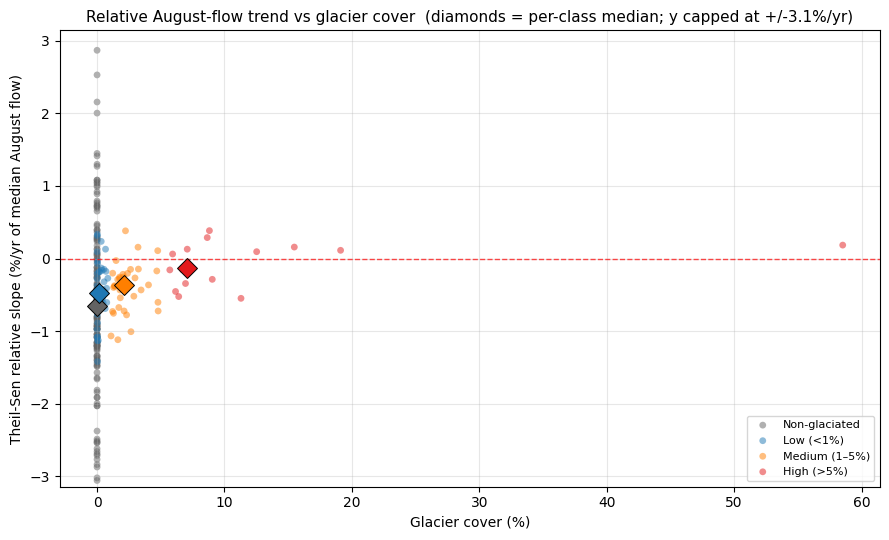

In [56]:
# Cell 7c: relative trend vs glacier cover — plain scatter view of the 7b gradient
# Descriptive only: per-station relative Theil-Sen slope vs glacier cover (%), colored by class,
# with each class median (plain np.median, no test) marked. Shows whether the decrease attenuates
# with glaciation and whether High (>5%) is flat vs just sparse, by eye.
d = (df_slopes[['rel_slope_pct_per_yr', 'glac_class']]
     .join(df_stn['glacier_pct']).dropna())

# Symmetric y-cap so a few small-median outliers don't squash the bulk (points beyond are clipped).
L = float(np.nanpercentile(d['rel_slope_pct_per_yr'].abs(), 97.5))

fig, ax = plt.subplots(figsize=(9, 5.5))
for c in GLAC_CLASS_LABELS:
    m = d['glac_class'] == c
    ax.scatter(d.loc[m, 'glacier_pct'], d.loc[m, 'rel_slope_pct_per_yr'],
               s=24, alpha=0.5, color=class_color[c], edgecolors='none', label=c)
    if m.sum():
        ax.plot(np.median(d.loc[m, 'glacier_pct']), np.median(d.loc[m, 'rel_slope_pct_per_yr']),
                'D', color=class_color[c], ms=10, mec='k', mew=0.7, zorder=6)

ax.axhline(0, color='red', lw=1, ls='--', alpha=0.7)
ax.set_ylim(-L, L)
ax.set_xlabel('Glacier cover (%)')
ax.set_ylabel('Theil-Sen relative slope (%/yr of median August flow)')
ax.set_title(f'Relative August-flow trend vs glacier cover  (diamonds = per-class median; '
             f'y capped at +/-{L:.1f}%/yr)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id="trend-vs-glacier-modelled"></a>
### Cell 7c-modelled — Relative trend vs glacier cover (MODELLED)

Mirror of 7c on **simulated** flow (phase-split ensemble mean). The sim Theil-Sen workflow isn't done elsewhere, so it's computed here: 10 members (mm/day, dated) → daily ensemble mean → August annual mean per station → per-station Theil-Sen slope as %/yr of median (units cancel, so directly comparable to the obs 7c). Ensemble **mean** is the right aggregate for a *trend* (the conditional-mean trend); it is *not* used for variance. Full modelled period (1980–2022) to match obs — note this includes the in-sample years (train ≤ 2005).

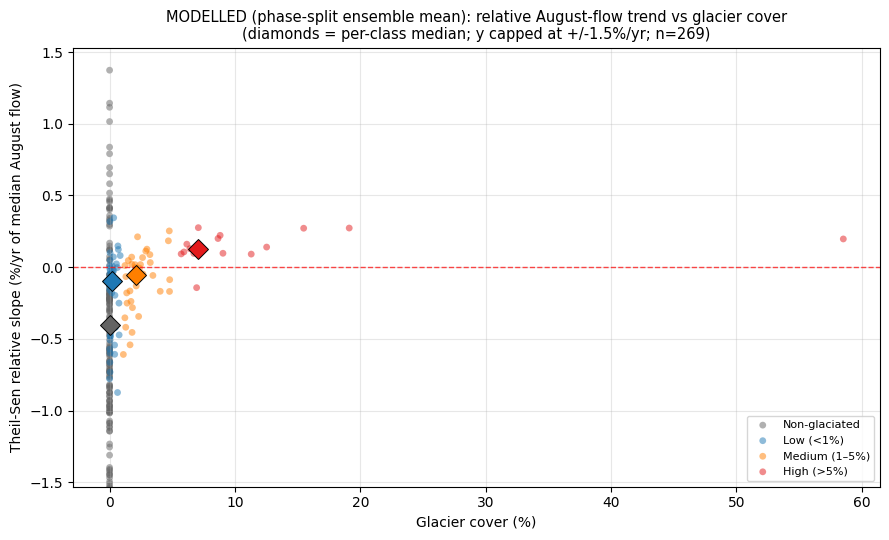

Modelled per-class median relative slope (%/yr):
glac_class
Non-glaciated   -0.404
Low (<1%)       -0.095
Medium (1–5%)   -0.052
High (>5%)       0.130


In [57]:
# Cell 7c-modelled: relative trend vs glacier cover — MODELLED data (phase-split ensemble mean)
# Mirror of obs Cell 7c. Sim Theil-Sen workflow built in-cell (not done elsewhere): load the 10
# phase-split members (mm/day, dated), average to the daily ensemble-mean series, take the August
# annual mean per station-year, then a per-station Theil-Sen slope as %/yr of that station's median
# August flow (units cancel -> comparable to obs 7c). Ensemble MEAN is right for a TREND (the
# conditional-mean trend); do NOT use it for variance (averaging suppresses variance) -- see methods.md.
from scipy.stats import theilslopes

N_MEMBERS = 10
MIN_YEARS = 10

# --- load members, restrict to analysis stations, build per-member August annual means ---
members_aug_sim = []
for i in range(N_MEMBERS):
    m = pd.read_csv(PHASE_SPLIT_DIR / f'phase-split_preds_member_{i}.csv', index_col=0, parse_dates=True)
    m = m[(m.index.year >= DATA_START_YEAR) & (m.index.year <= DATA_END_YEAR)]
    aug = m[m.index.month == 8]
    members_aug_sim.append(aug.groupby(aug.index.year).mean())

# stations present in df_stn AND every member; ensemble-mean August series (one per station)
common = set(df_stn.index)
for a in members_aug_sim:
    common &= set(a.columns)
common = sorted(common)
sim_aug = sum(a[common] for a in members_aug_sim) / N_MEMBERS

# --- per-station Theil-Sen relative slope on the sim ensemble-mean August series ---
recs = {}
for stn in sim_aug.columns:
    s = sim_aug[stn].dropna()
    if len(s) < MIN_YEARS:
        recs[stn] = np.nan
        continue
    slope = theilslopes(s.values, s.index.values.astype(float)).slope
    med = s.median()
    recs[stn] = 100 * slope / med if med > 0 else np.nan

df_slopes_sim = pd.DataFrame({'rel_slope_pct_per_yr': pd.Series(recs)})
df_slopes_sim['glac_class'] = df_stn['glac_class']

# --- scatter (mirror of 7c) ---
d = df_slopes_sim.join(df_stn['glacier_pct']).dropna()
L = float(np.nanpercentile(d['rel_slope_pct_per_yr'].abs(), 97.5))   # symmetric y-cap (outliers clipped)

fig, ax = plt.subplots(figsize=(9, 5.5))
for c in GLAC_CLASS_LABELS:
    msk = d['glac_class'] == c
    ax.scatter(d.loc[msk, 'glacier_pct'], d.loc[msk, 'rel_slope_pct_per_yr'],
               s=24, alpha=0.5, color=class_color[c], edgecolors='none', label=c)
    if msk.sum():
        ax.plot(np.median(d.loc[msk, 'glacier_pct']), np.median(d.loc[msk, 'rel_slope_pct_per_yr']),
                'D', color=class_color[c], ms=10, mec='k', mew=0.7, zorder=6)

ax.axhline(0, color='red', lw=1, ls='--', alpha=0.7)
ax.set_ylim(-L, L)
ax.set_xlabel('Glacier cover (%)')
ax.set_ylabel('Theil-Sen relative slope (%/yr of median August flow)')
ax.set_title('MODELLED (phase-split ensemble mean): relative August-flow trend vs glacier cover\n'
             f'(diamonds = per-class median; y capped at +/-{L:.1f}%/yr; n={len(d)})', fontsize=10.5)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Modelled per-class median relative slope (%/yr):")
print(d.groupby('glac_class', observed=False)['rel_slope_pct_per_yr'].median().round(3).to_string())

<a id="trend-mk"></a>
### Cell 7d — Mann-Kendall: does the slope trend monotonically with glacier cover?

Backs the 7c visual with a single rank test. MK on `rel_slope` ordered by `glacier_pct` over glaciated basins tests whether the relative trend moves monotonically with glacier cover — **existence and direction** of the association, not magnitude (the scatter carries magnitude). Plain `original_test`, not the Hamed-Rao AR(1) variant (that is for time-series serial dependence; here the index is a covariate).

Caveats unchanged from 7b: spatial autocorrelation makes p **anti-conservative** (read directional), and `glacier_pct` is confounded with elevation / area — a trend here is association with cover, not proof glaciation drives it.

In [53]:
# Cell 7d: Mann-Kendall test for a monotonic trend in relative slope vs glacier cover (glaciated only)
# Q (from 7b/7c): within glaciated basins, does rel_slope trend monotonically with glacier cover?
# MK on rel_slope ORDERED BY glacier_pct = rank test of that association (= Kendall tau of the two).
# original_test, NOT Hamed-Rao: AR(1) correction is for a TIME series; the index here is a covariate,
# so AR(1) is not the relevant structure. Spatial autocorrelation across basins is the real, UNCORRECTED
# dependence -> p directional only. glacier_pct is confounded w/ elevation/area: association, not cause.
g = (df_slopes[['rel_slope_pct_per_yr']]
     .join(df_stn['glacier_pct'])
     .dropna()
     .query('glacier_pct > 0')
     .sort_values('glacier_pct'))

mk_res = mk.original_test(g['rel_slope_pct_per_yr'].values)
print(f"Mann-Kendall (rel_slope ordered by glacier cover, glaciated n={len(g)}):")
print(f"  trend      : {mk_res.trend}")
print(f"  tau        : {mk_res.Tau:+.3f}")
print(f"  S          : {mk_res.s:.0f}")
print(f"  p (2-sided): {mk_res.p:.4g}")
print("  NOTE: spatial autocorrelation -> p anti-conservative (directional only); "
      "glacier_pct confounded with elevation/area.")

Mann-Kendall (rel_slope ordered by glacier cover, glaciated n=95):
  trend      : increasing
  tau        : +0.249
  S          : 1113
  p (2-sided): 0.00035
  NOTE: spatial autocorrelation -> p anti-conservative (directional only); glacier_pct confounded with elevation/area.


<a id="size-by-glaciation"></a>
### Cell 7e — Glacier size: distribution and trend vs absolute glacier area

Per the PI, the property of interest is **glacier size** — absolute ice area (km²) — not basin size. Glacier area = `basin_area_km2 × glacier_pct / 100`, glaciated basins only.

- **Left:** density of glacier size by regime (Low / Medium / High), log scale, solid line = median.
- **Right:** per-station **percent change** (relative Theil-Sen slope, %/yr) against glacier size **continuously** — as a function of the property itself, not the Low/Med/High bin membership. (Distinct from 7c, which is vs glacier *% cover*; this is vs glacier *absolute size*.) Symmetric y-cap, 0 line; colored by regime for reference only.

Still a confounder note: glacier size correlates with basin size, so a trend vs glacier area is association, not isolated causation.

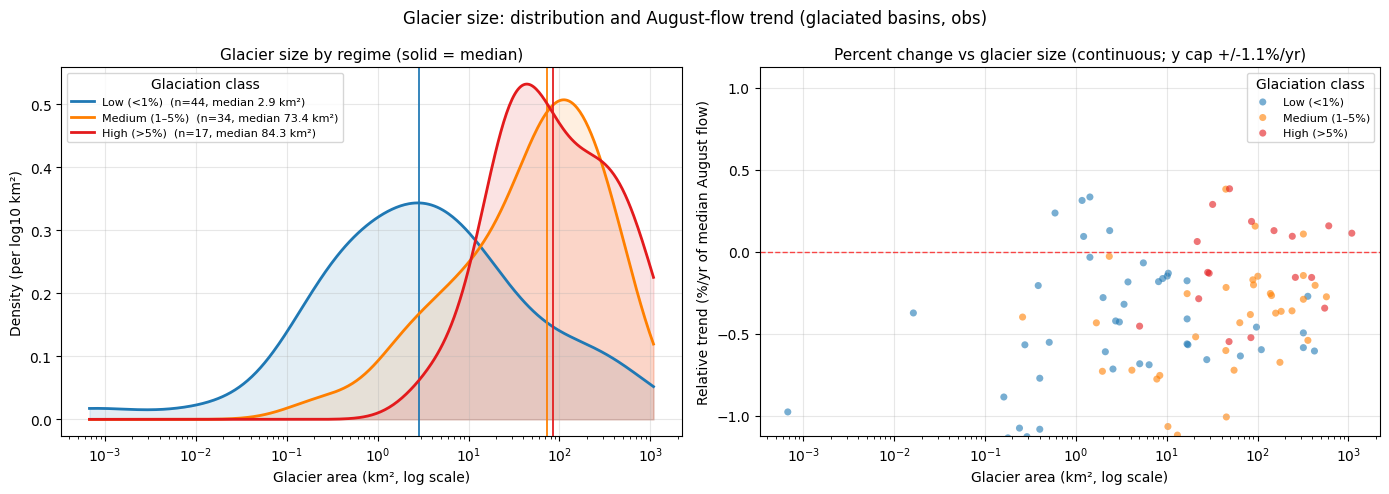

In [60]:
# Cell 7e: glacier SIZE (absolute ice area) — distribution by regime + percent-change vs the property
# PI clarification: property of interest is glacier size (km^2 of ice), not basin size.
# glacier_area_km2 = basin_area_km2 * glacier_pct / 100, glaciated basins only.
# Right panel = %-change (rel Theil-Sen slope, obs) as a CONTINUOUS function of glacier size,
# rather than by Low/Med/High bin membership (7b-7d). NB 7c is vs glacier % cover; this is vs km^2 ice.
from scipy.stats import gaussian_kde

g = df_stn[['basin_area_km2', 'glacier_pct', 'glac_class']].copy()
g['glacier_area_km2'] = g['basin_area_km2'] * g['glacier_pct'] / 100.0
g = g[g['glacier_pct'] > 0]                       # glaciated only (area > 0 for log axis)
g = g.join(df_slopes['rel_slope_pct_per_yr'])     # obs relative trend, %/yr

glac_classes = GLAC_CLASS_LABELS[1:]              # Low, Medium, High
fig, (axD, axS) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: density of glacier size by regime (log scale) ---
pooled = np.log10(g['glacier_area_km2'].dropna().values)
xx = np.linspace(pooled.min(), pooled.max(), 400)
for c in glac_classes:
    v = g.loc[g['glac_class'] == c, 'glacier_area_km2'].dropna().values
    if len(v) < 2:
        continue
    kde = gaussian_kde(np.log10(v))
    col = class_color[c]
    axD.plot(10**xx, kde(xx), color=col, lw=2, label=f"{c}  (n={len(v)}, median {np.median(v):,.1f} km²)")
    axD.fill_between(10**xx, kde(xx), color=col, alpha=0.12)
    axD.axvline(np.median(v), color=col, lw=1.4, ls='-', alpha=0.9)
axD.set_xscale('log')
axD.set_xlabel('Glacier area (km², log scale)')
axD.set_ylabel('Density (per log10 km²)')
axD.set_title('Glacier size by regime (solid = median)', fontsize=11)
axD.legend(fontsize=8, title='Glaciation class')
axD.grid(alpha=0.3)

# --- Right: percent change (%/yr) vs glacier size, continuous ---
d = g.dropna(subset=['rel_slope_pct_per_yr', 'glacier_area_km2'])
L = float(np.nanpercentile(d['rel_slope_pct_per_yr'].abs(), 97.5))
for c in glac_classes:
    m = d['glac_class'] == c
    axS.scatter(d.loc[m, 'glacier_area_km2'], d.loc[m, 'rel_slope_pct_per_yr'],
                s=26, alpha=0.6, color=class_color[c], edgecolors='none', label=c)
axS.axhline(0, color='red', lw=1, ls='--', alpha=0.7)
axS.set_xscale('log')
axS.set_ylim(-L, L)
axS.set_xlabel('Glacier area (km², log scale)')
axS.set_ylabel('Relative trend (%/yr of median August flow)')
axS.set_title(f'Percent change vs glacier size (continuous; y cap +/-{L:.1f}%/yr)', fontsize=11)
axS.legend(fontsize=8, title='Glaciation class')
axS.grid(alpha=0.3)

fig.suptitle('Glacier size: distribution and August-flow trend (glaciated basins, obs)', fontsize=12)
plt.tight_layout()
plt.show()

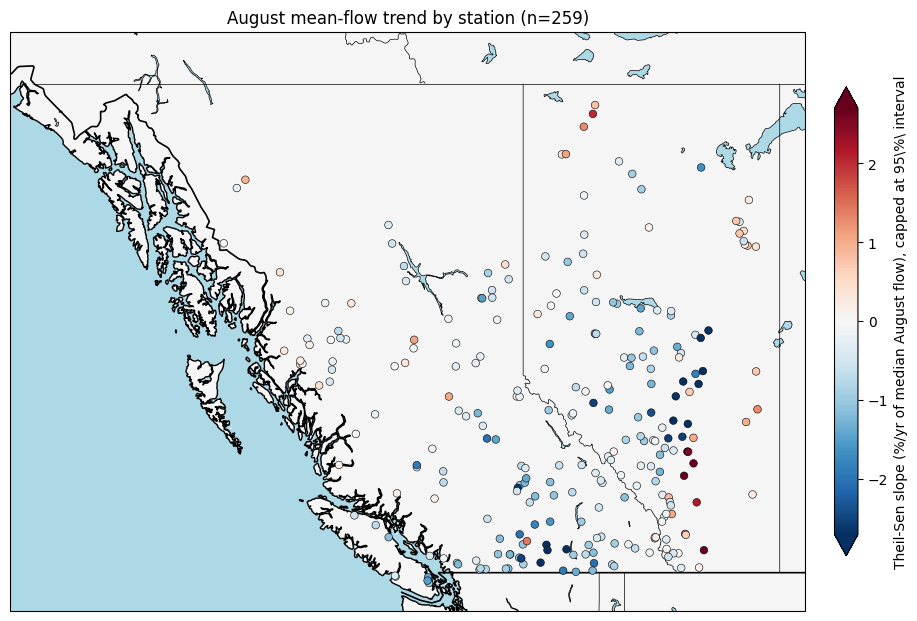

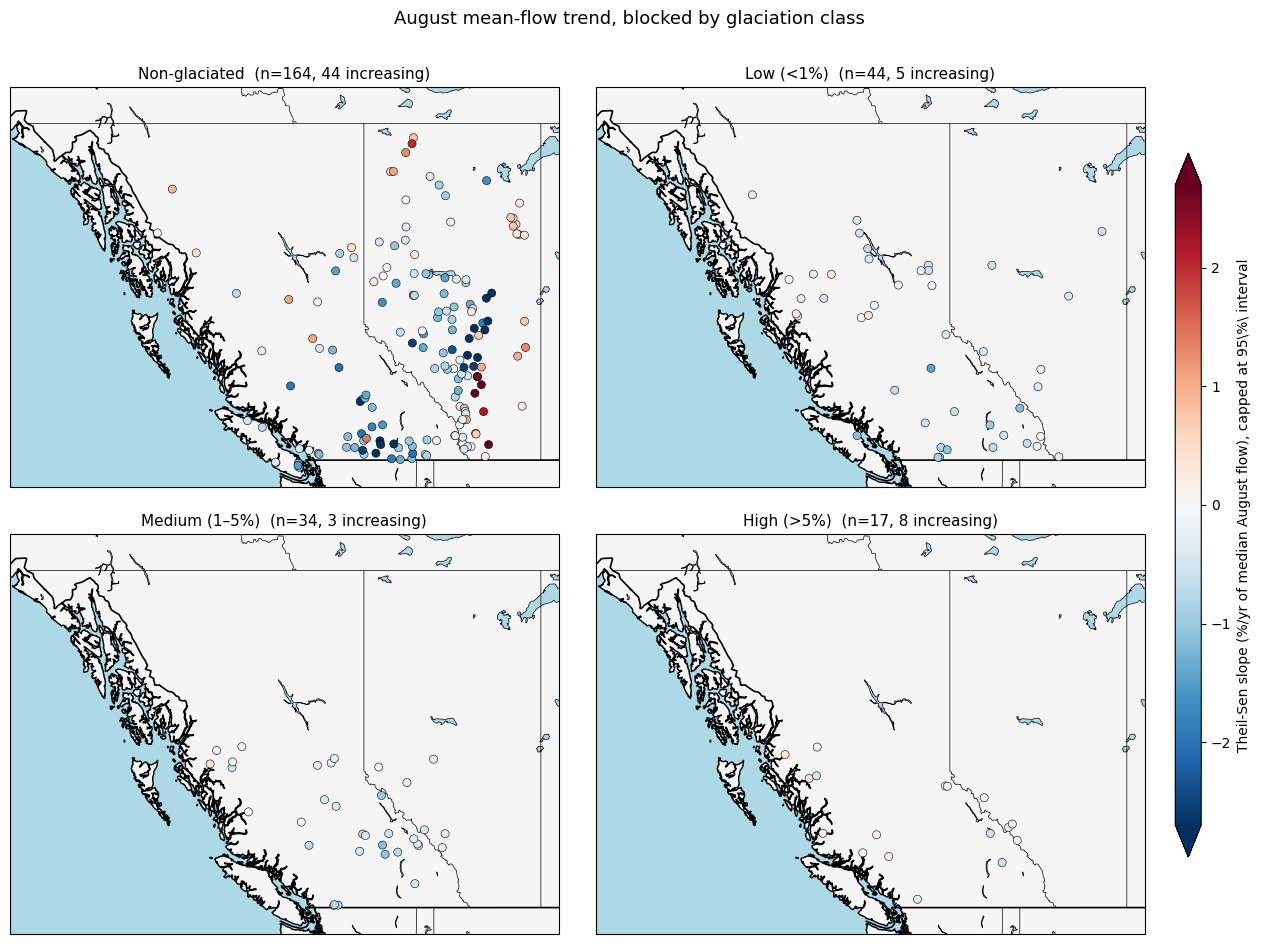

In [35]:
# Cell 8: Trend maps — Theil-Sen slope in space (relative %/yr, diverging scale)
# Map 1: all stations colored by slope. Map 2: same color scale, one panel per glaciation bin.
SLOPE_CMAP = 'RdBu_r'   # red = increasing, blue = decreasing (matches the sparkline grid)

plot_df = (df_stn[['longitude', 'latitude', 'glac_class']]
           .join(df_slopes['rel_slope_pct_per_yr'])
           .dropna(subset=['rel_slope_pct_per_yr']))

# Symmetric, robust color limits (95th pct of |slope|) so a few small-median outliers
# don't wash out the scale; colorbar extends beyond.
lim = round(float(np.nanpercentile(plot_df['rel_slope_pct_per_yr'].abs(), 95)), 1)

# ---------------------------------------------------------
# Map 1: all stations
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.Mercator())
draw_base(ax)
sc = ax.scatter(
    plot_df['longitude'], plot_df['latitude'], transform=ccrs.PlateCarree(),
    c=plot_df['rel_slope_pct_per_yr'], cmap=SLOPE_CMAP, vmin=-lim, vmax=lim,
    s=30, marker='o', edgecolors='k', linewidths=0.4, zorder=5,
)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.03, extend='both')
cbar.set_label('Theil-Sen slope (%/yr of median August flow), capped at 95\%\ interval', fontsize=10)
plt.title(f"August mean-flow trend by station (n={len(plot_df)})", fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Map 2: blocked by glaciation class (shared color scale)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         subplot_kw={'projection': ccrs.Mercator()})
for ax, label in zip(axes.flat, GLAC_CLASS_LABELS):
    draw_base(ax)
    grp = plot_df[plot_df['glac_class'] == label]
    sc = ax.scatter(
        grp['longitude'], grp['latitude'], transform=ccrs.PlateCarree(),
        c=grp['rel_slope_pct_per_yr'], cmap=SLOPE_CMAP, vmin=-lim, vmax=lim,
        s=34, marker='o', edgecolors='k', linewidths=0.4, zorder=5,
    )
    n_inc = int((grp['rel_slope_pct_per_yr'] > 0).sum())
    ax.set_title(f"{label}  (n={len(grp)}, {n_inc} increasing)", fontsize=11)

fig.subplots_adjust(left=0.02, right=0.9, wspace=0.05, hspace=0.12)
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.64])
cbar = fig.colorbar(sc, cax=cbar_ax, extend='both')
cbar.set_label('Theil-Sen slope (%/yr of median August flow), capped at 95\%\ interval', fontsize=10)
fig.suptitle('August mean-flow trend, blocked by glaciation class', fontsize=13, y=0.95)
plt.show()

Map 1 — every station as a point colored by its Theil-Sen slope on a diverging RdBu_r scale (red = increasing, blue = decreasing, matching the sparkline grid), using relative %/yr so basins of different sizes are comparable. Scale is symmetric and capped at the 95th percentile of |slope| (≈ ±2.7%/yr) with extend='both' so the handful of small-median outliers don't flatten the colors.

Map 2 — same color scale and units, but split into a 2×2 panel grid, one per glaciation bin (Non-glaciated / Low / Medium / High), with a single shared colorbar. Each panel title notes n and how many are increasing — so you can read the spatial slope pattern within each glaciation class side by side.

Notice none of the glaciated basins are increasing >> 0% of median.

<a id="som"></a>
## 5. Self-Organizing Maps (Step 3)

Cluster the 269 stations by their **August mean-flow trajectory** (1980–2022, 43 values), per the PI's Step 3. Each station is one sample; its 43 August values (z-scored per station so we cluster on *temporal shape*, not basin magnitude) are the features. A 2×2 SOM (4 nodes) to start.

Two SOMs, to see what the trend adds:
- **No-slope** — features = the 43 z-scored August values only.
- **With Theil-Sen** — same 43 values **plus** the relative Theil-Sen slope as a weighted supporting feature (`SLOPE_WEIGHT`, ~21% of feature variance — enough to reorganize the map without collapsing a node).

SOM is a self-contained NumPy batch implementation (no new dependency). For each SOM we show node mean patterns, a station map colored by node, and a glaciated/non-glaciated breakdown per node.

In [36]:
# Cell 9: SOM setup + train both variants on August mean-flow trajectories
from scipy.optimize import linear_sum_assignment

SOM_GRID = (2, 2)       # 2x2 = 4 nodes to start
SOM_ITERS = 300
SOM_SEED = 42
SLOPE_WEIGHT = 3.5      # weight on the Theil-Sen feature (~21% of feature variance)

def train_som(X, grid=SOM_GRID, n_iter=SOM_ITERS, seed=SOM_SEED):
    """Minimal deterministic batch SOM. Returns (weights, bmu_index_per_sample, node_coords)."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    g0, g1 = grid
    coords = np.array([[i, j] for i in range(g0) for j in range(g1)], dtype=float)
    W = X[rng.choice(n, g0 * g1, replace=False)].copy()
    sigma0 = max(g0, g1) / 2
    for t in range(n_iter):
        sigma = max(sigma0 * (0.2 / sigma0) ** (t / n_iter), 1e-3)
        bmu = ((X[:, None, :] - W[None, :, :]) ** 2).sum(-1).argmin(1)
        gd2 = ((coords[bmu][:, None, :] - coords[None, :, :]) ** 2).sum(-1)
        h = np.exp(-gd2 / (2 * sigma ** 2))
        W = (h.T @ X) / h.sum(0)[:, None]
    bmu = ((X[:, None, :] - W[None, :, :]) ** 2).sum(-1).argmin(1)
    return W, bmu, coords

# --- Feature matrix: per-station z-scored August trajectory (269 x 43) ---
som_stations = list(aug_flow.columns)
aug_filled = aug_flow.interpolate(limit_direction='both')        # fill the few interior/edge gaps
X_shape = aug_filled.T.values                                    # stations x years
X_shape = (X_shape - X_shape.mean(1, keepdims=True)) / X_shape.std(1, keepdims=True)

# --- Train ---
_, bmu_noslope, _ = train_som(X_shape)

# --- Report node sizes + how much the trend reorganized things ---
print(f"SOM   node sizes: {np.bincount(bmu_noslope, minlength=4).tolist()}")
C = np.zeros((4, 4), int)

SOM   node sizes: [84, 56, 46, 83]


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


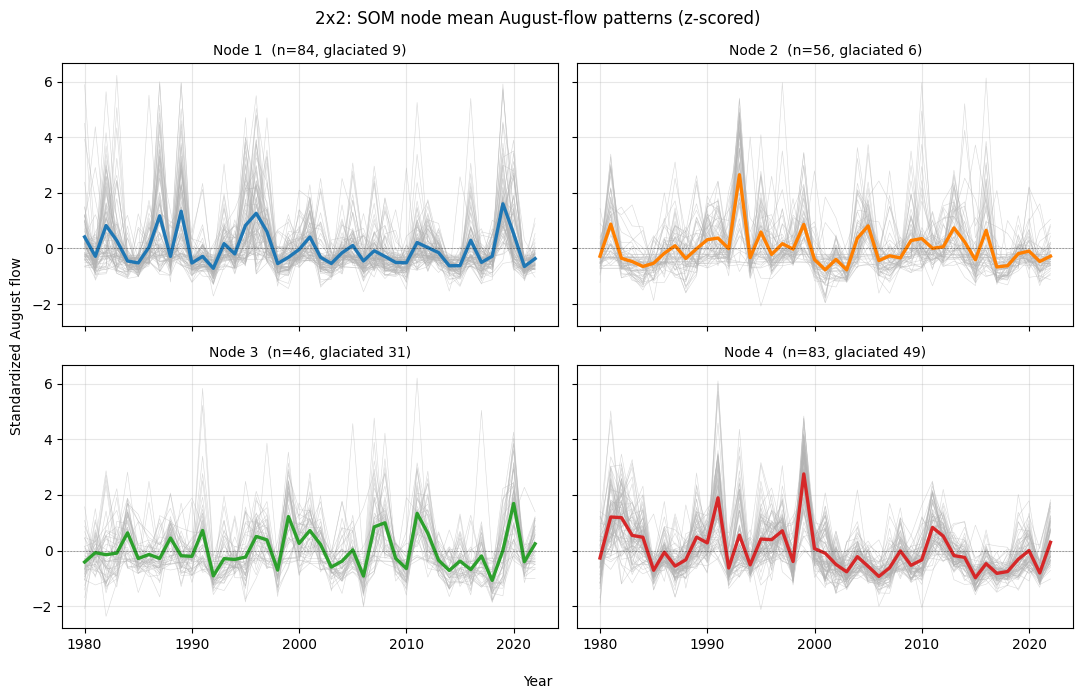

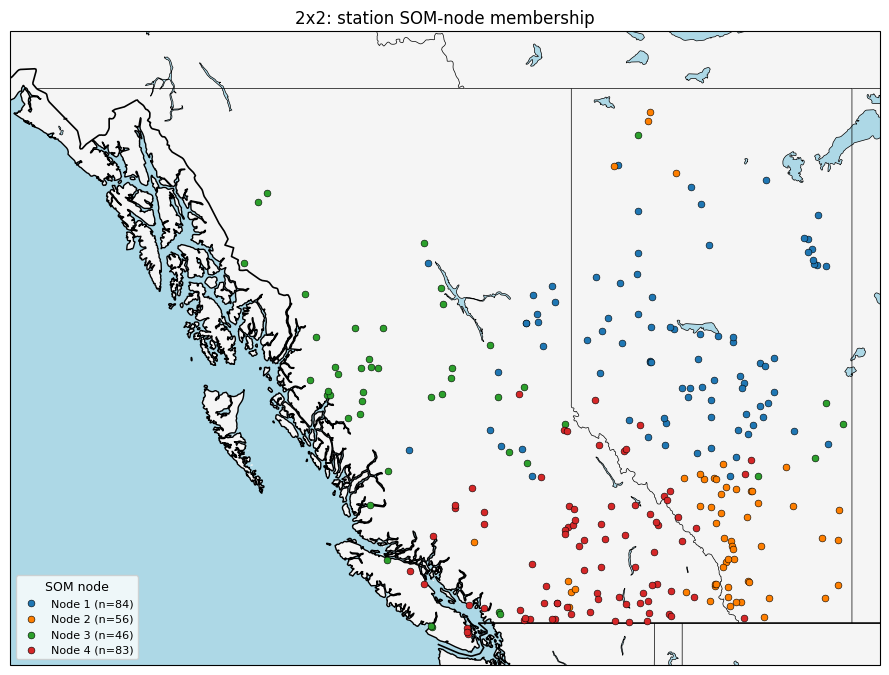

2x2: stations per node by glaciation


glac_class,Non-glaciated,Low (<1%),Medium (1–5%),High (>5%),glaciated,non_glaciated,total
node,,,,,,,
1,75,8,1,0,9,75,84
2,50,4,1,1,6,50,56
3,15,16,10,5,31,15,46
4,34,16,22,11,49,34,83


In [37]:
# Cell 10: Plot the 269 stations organized by SOM node — patterns, map, glaciation breakdown
NODE_COLORS = ['#1f77b4', '#ff7f00', '#2ca02c', '#d62728']
years = aug_flow.index.values
stns = np.array(som_stations)

def plot_som(title, bmu):
    # --- Node mean patterns (2x2, matching the SOM grid) ---
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
    for node, ax in enumerate(axes.flat):
        members = stns[bmu == node]
        M = X_shape[bmu == node]
        if len(members):
            ax.plot(years, M.T, color='0.7', lw=0.4, alpha=0.5)
            ax.plot(years, M.mean(0), color=NODE_COLORS[node], lw=2.4)
        n_glac = int(df_stn.loc[members, 'glaciated'].sum()) if len(members) else 0
        ax.set_title(f"Node {node + 1}  (n={len(members)}, glaciated {n_glac})", fontsize=10)
        ax.axhline(0, color='k', lw=0.4, ls=':')
        ax.grid(alpha=0.3)
    fig.suptitle(f"{title}: SOM node mean August-flow patterns (z-scored)", fontsize=12)
    fig.supxlabel('Year', fontsize=10)
    fig.supylabel('Standardized August flow', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Station map colored by node ---
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.Mercator())
    draw_base(ax)
    for node in range(4):
        members = stns[bmu == node]
        if not len(members):
            continue
        ax.scatter(
            df_stn.loc[members, 'longitude'], df_stn.loc[members, 'latitude'],
            transform=ccrs.PlateCarree(), color=NODE_COLORS[node],
            s=24, marker='o', edgecolors='k', linewidths=0.4, zorder=5,
            label=f'Node {node + 1} (n={len(members)})',
        )
    ax.legend(loc='lower left', fontsize=8, title='SOM node', title_fontsize=9)
    plt.title(f"{title}: station SOM-node membership", fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- Glaciation breakdown per node ---
    org = df_stn.loc[stns, ['glac_class', 'glaciated']].copy()
    org['node'] = bmu + 1
    by_class = pd.crosstab(org['node'], org['glac_class'])
    by_class['glaciated'] = org.groupby('node')['glaciated'].sum().astype(int)
    by_class['non_glaciated'] = org.groupby('node').size() - by_class['glaciated']
    by_class['total'] = org.groupby('node').size()
    print(f"{title}: stations per node by glaciation")
    display(by_class)

plot_som('2x2', bmu_noslope)

### 3×2 SOM (6 nodes)

Same data and procedure as the 2×2, just a 6-node grid. The EOSC 410 reference reported:

> 3×2 captures more detail than 2×2; the largest BMU changes occur at complex-terrain (mountain) and downstream stations. The glacier-runoff-dominated pattern (node 3 in 3×2) is a refined split of the glaciated node from the 2×2 (node 4 in their setup). Both "node 1"s captured the same pattern.

We can check the analogous claim here by looking at:
- the 3×2 node patterns + station map (against the 2×2 versions above),
- a 2×2 vs 3×2 contingency table (which 2×2 node splits into which 3×2 nodes),
- and where the glaciated stations land in 3×2 — does the previously-mixed glaciated node refine into a tighter glacier-dominated cluster?

Note: a 6-node grid carves more finely than a 4-node one, so the slope feature has to be down-weighted to stay non-degenerate. We use `SLOPE_WEIGHT_3X2 = 2.5` (about 12% of feature variance) here; at the 2×2 value of 3.5 a node collapses to one station.

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


3x2   node sizes: [37, 78, 28, 37, 47, 42]


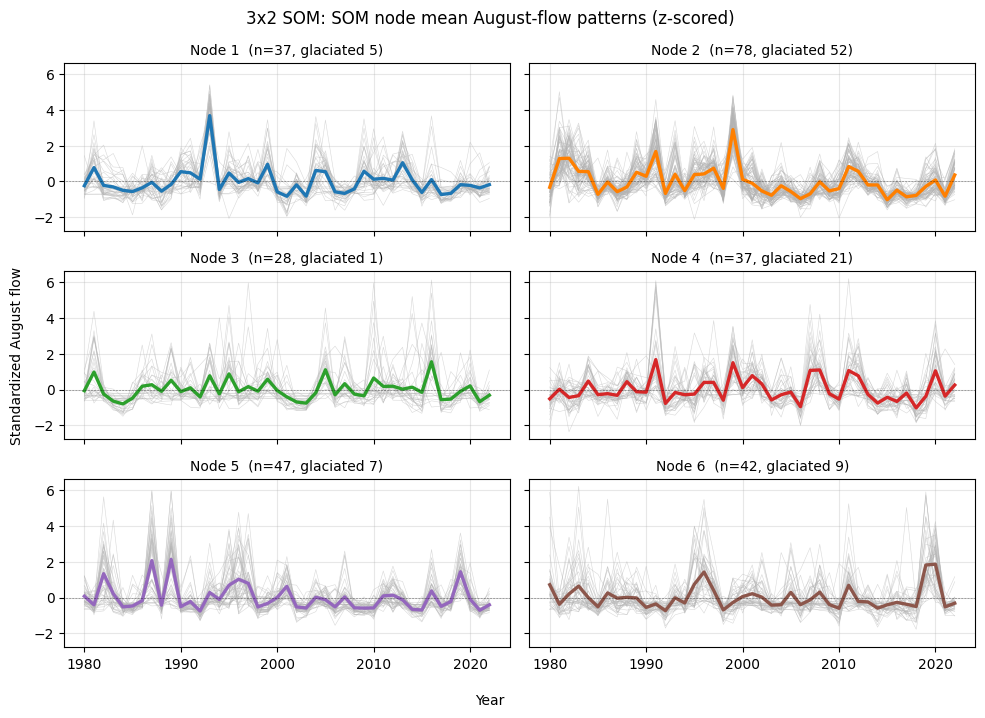

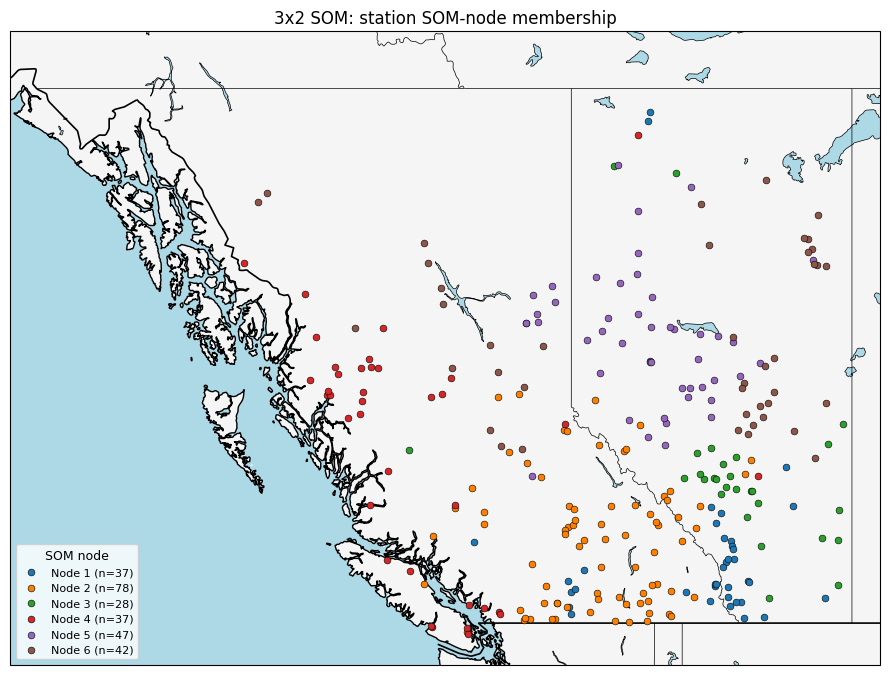

3x2 SOM: stations per node by glaciation


glac_class,Non-glaciated,Low (<1%),Medium (1–5%),High (>5%),glaciated,non_glaciated,total
node,,,,,,,
1,32,4,0,1,5,32,37
2,26,15,26,11,52,26,78
3,27,1,0,0,1,27,28
4,16,10,6,5,21,16,37
5,40,6,1,0,7,40,47
6,33,8,1,0,9,33,42



2x2 vs 3x2: rows = 2x2 node, cols = 3x2 node, values = station count


3x2 node,1,2,3,4,5,6
2x2 node,,,,,,
1,0,0,6,0,47,31
2,34,1,21,0,0,0
3,0,3,1,31,0,11
4,3,74,0,6,0,0


In [38]:
# Cell 11: 3x2 SOM; compare to the 2x2 above
SOM_GRID_3X2 = (3, 2)

_, bmu_noslope_3x2, _ = train_som(X_shape, grid=SOM_GRID_3X2)

print(f"3x2   node sizes: {np.bincount(bmu_noslope_3x2, minlength=6).tolist()}")

NODE_COLORS_6 = ['#1f77b4', '#ff7f00', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

def plot_som_grid(title, bmu, grid, colors):
    g0, g1 = grid
    n_nodes = g0 * g1

    # --- Node mean patterns laid out in the SOM grid orientation ---
    fig, axes = plt.subplots(g0, g1, figsize=(g1 * 5.0, g0 * 2.4), sharex=True, sharey=True)
    for node, ax in enumerate(axes.flat):
        members = stns[bmu == node]
        M = X_shape[bmu == node]
        if len(members):
            ax.plot(years, M.T, color='0.7', lw=0.4, alpha=0.5)
            ax.plot(years, M.mean(0), color=colors[node], lw=2.4)
        n_glac = int(df_stn.loc[members, 'glaciated'].sum()) if len(members) else 0
        ax.set_title(f"Node {node + 1}  (n={len(members)}, glaciated {n_glac})", fontsize=10)
        ax.axhline(0, color='k', lw=0.4, ls=':')
        ax.grid(alpha=0.3)
    fig.suptitle(f"{title}: SOM node mean August-flow patterns (z-scored)", fontsize=12)
    fig.supxlabel('Year', fontsize=10)
    fig.supylabel('Standardized August flow', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Station map ---
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.Mercator())
    draw_base(ax)
    for node in range(n_nodes):
        members = stns[bmu == node]
        if not len(members):
            continue
        ax.scatter(
            df_stn.loc[members, 'longitude'], df_stn.loc[members, 'latitude'],
            transform=ccrs.PlateCarree(), color=colors[node],
            s=24, marker='o', edgecolors='k', linewidths=0.4, zorder=5,
            label=f'Node {node + 1} (n={len(members)})',
        )
    ax.legend(loc='lower left', fontsize=8, title='SOM node', title_fontsize=9)
    plt.title(f"{title}: station SOM-node membership", fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- Glaciation breakdown ---
    org = df_stn.loc[stns, ['glac_class', 'glaciated']].copy()
    org['node'] = bmu + 1
    bc = pd.crosstab(org['node'], org['glac_class'])
    bc['glaciated'] = org.groupby('node')['glaciated'].sum().astype(int)
    bc['non_glaciated'] = org.groupby('node').size() - bc['glaciated']
    bc['total'] = org.groupby('node').size()
    print(f"{title}: stations per node by glaciation")
    display(bc)

plot_som_grid('3x2 SOM',       bmu_noslope_3x2, SOM_GRID_3X2, NODE_COLORS_6)

# --- 2x2 -> 3x2 refinement contingency: how each 2x2 node splits ---
print("\n2x2 vs 3x2: rows = 2x2 node, cols = 3x2 node, values = station count")
display(pd.crosstab(pd.Series(bmu_noslope + 1, name='2x2 node'),
                    pd.Series(bmu_noslope_3x2 + 1, name='3x2 node')))

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


3x4 node sizes: [26, 24, 19, 23, 22, 6, 13, 22, 43, 28, 22, 21]


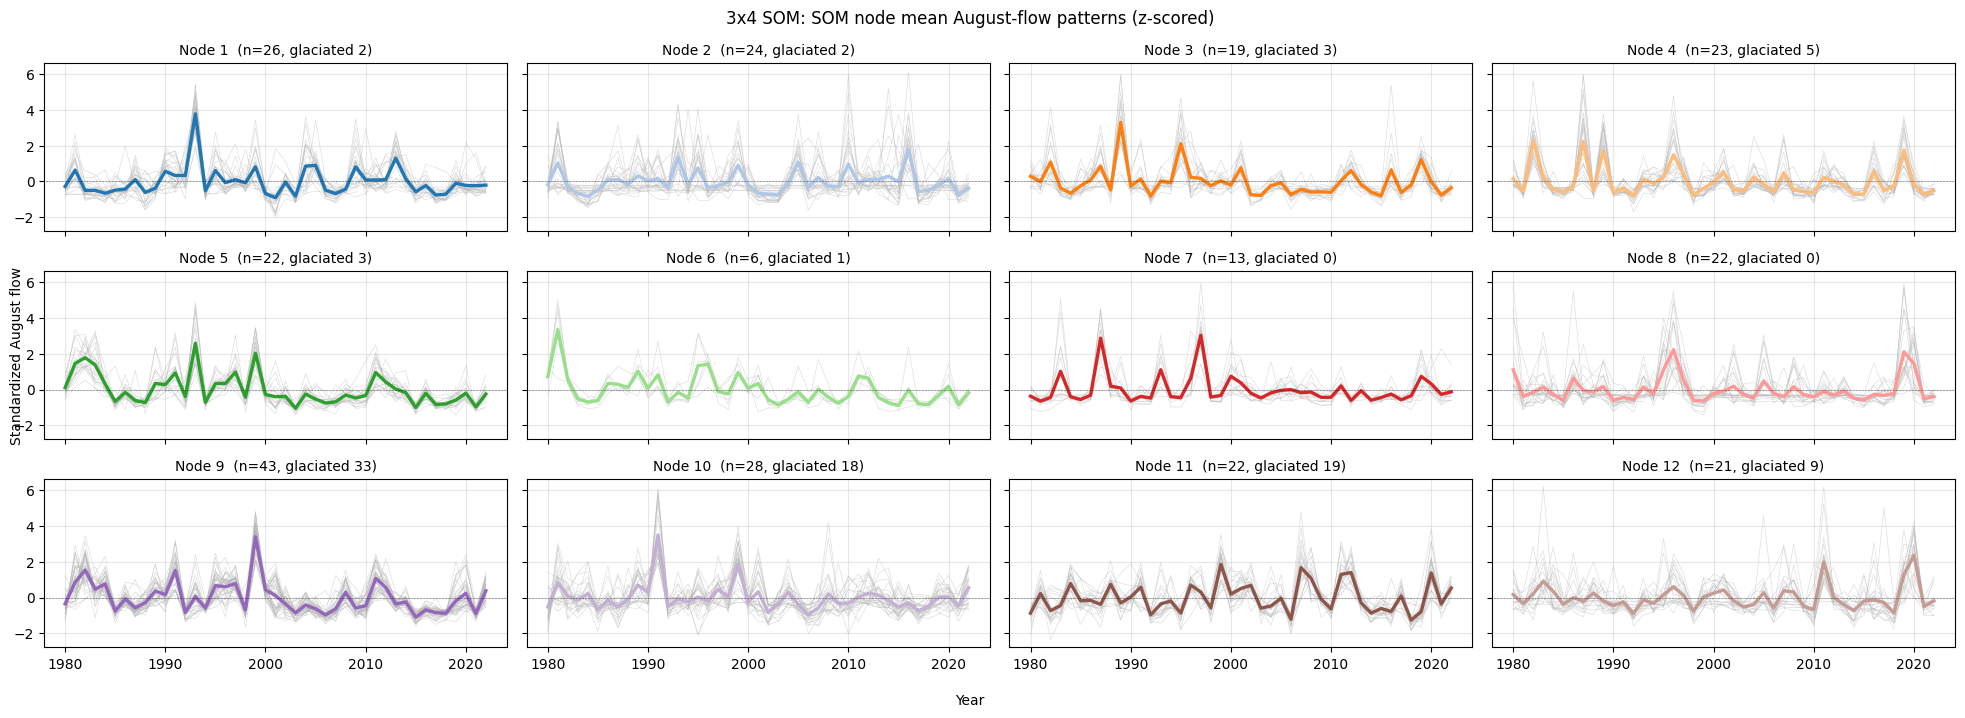

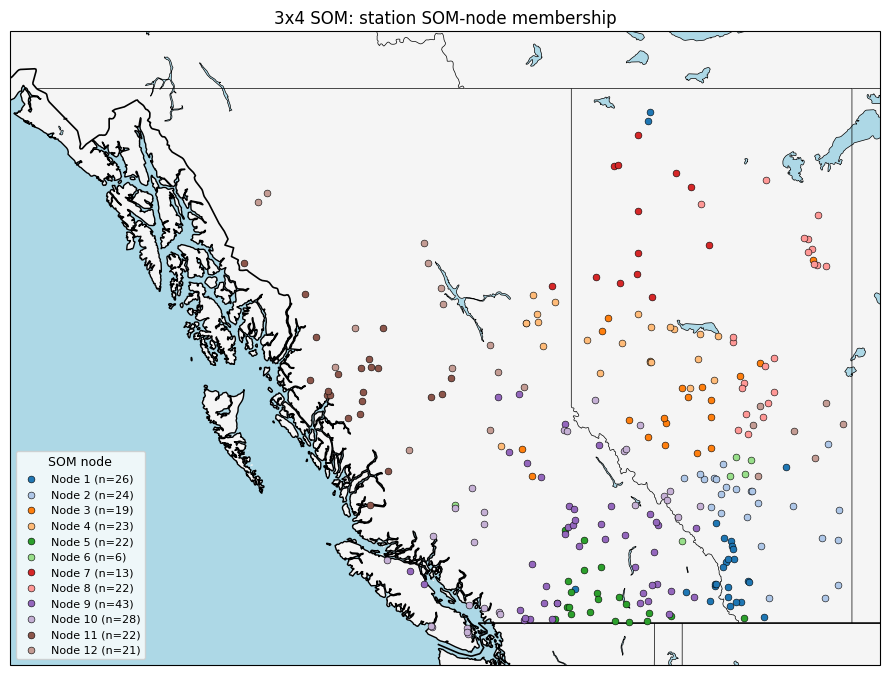

3x4 SOM: stations per node by glaciation


glac_class,Non-glaciated,Low (<1%),Medium (1–5%),High (>5%),glaciated,non_glaciated,total
node,,,,,,,
1,24,2,0,0,2,24,26
2,22,2,0,0,2,22,24
3,16,2,1,0,3,16,19
4,18,5,0,0,5,18,23
5,19,3,0,0,3,19,22
6,5,1,0,0,1,5,6
7,13,0,0,0,0,13,13
8,22,0,0,0,0,22,22
9,10,11,20,2,33,10,43



2x2 vs 3x4: rows = 2x2 node, cols = 3x4 node, values = station count


3x4 node,1,2,3,4,5,6,7,8,9,10,11,12
2x2 node,,,,,,,,,,,,
1,0,1,19,23,0,2,10,22,0,0,0,7
2,26,23,0,0,3,0,2,0,0,2,0,0
3,0,0,0,0,0,0,1,0,4,5,22,14
4,0,0,0,0,19,4,0,0,39,21,0,0


In [39]:
# Cell 12: 3x4 SOM — no-slope; compare to the 2x2 above
# Reuses plot_som_grid() defined in the 3x2 cell above.
SOM_GRID_3X4 = (3, 4)
N_NODES_3X4 = SOM_GRID_3X4[0] * SOM_GRID_3X4[1]   # 12 nodes

_, bmu_noslope_3x4, _ = train_som(X_shape, grid=SOM_GRID_3X4)

print(f"3x4 node sizes: {np.bincount(bmu_noslope_3x4, minlength=N_NODES_3X4).tolist()}")

# 12 distinct colors (NODE_COLORS_6 only had 6 -> IndexError past node 6)
NODE_COLORS_12 = [plt.cm.tab20(i) for i in range(N_NODES_3X4)]

plot_som_grid('3x4 SOM', bmu_noslope_3x4, SOM_GRID_3X4, NODE_COLORS_12)

# --- 2x2 -> 3x4 refinement contingency: how each 2x2 node splits ---
print("\n2x2 vs 3x4: rows = 2x2 node, cols = 3x4 node, values = station count")
display(pd.crosstab(pd.Series(bmu_noslope + 1, name='2x2 node'),
                    pd.Series(bmu_noslope_3x4 + 1, name='3x4 node')))

<a id="subgroup-som"></a>
## 6. Subgroup SOMs (Step 4)

Instead of one SOM over all stations, train the SOM **separately** on the glaciated and non-glaciated subsets, to surface the characteristic August streamflow shapes *within* each group before any trend analysis.

- **Separation** reuses the earlier flag, `glaciated = glacier_pct > 0` (no glacier-% threshold applied) — realized counts are printed by the cell below.
- **Features** are the same per-station z-scored August trajectories as Step 3 (shape, not magnitude). Z-scores are computed per station, so subsetting rows needs no renormalization.
- **Grids:** 2×2 and 3×4 per subgroup, matching Step 3.

Each SOM shows the per-node mean August-flow pattern, the station map, and a per-node breakdown. (For the non-glaciated subset the per-node glaciation breakdown is trivially all-`Non-glaciated`; the node *sizes* and *patterns* are the point.)

Glaciation split (glacier_pct > 0): glaciated n=95, non-glaciated n=174, total n=269

===== Glaciated: n=95 stations =====
Glaciated 2x2 node sizes: [23, 21, 26, 25]


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


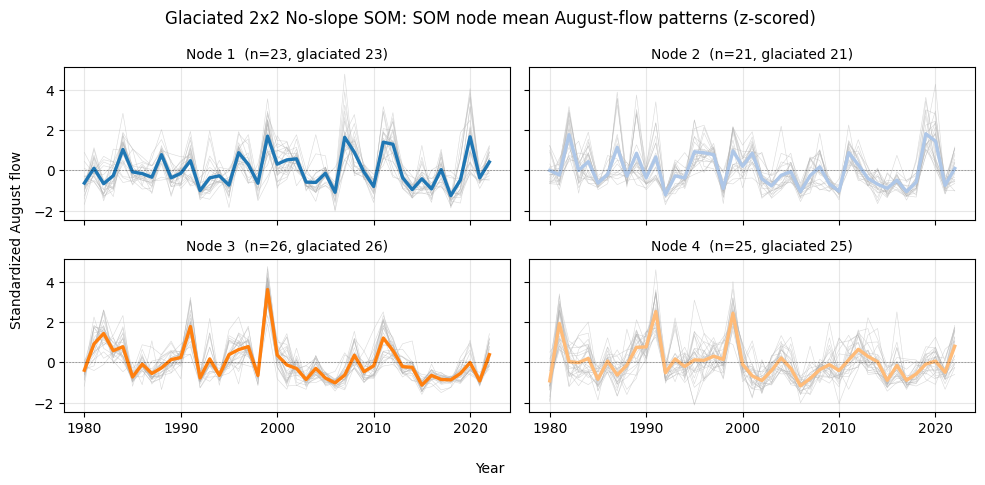

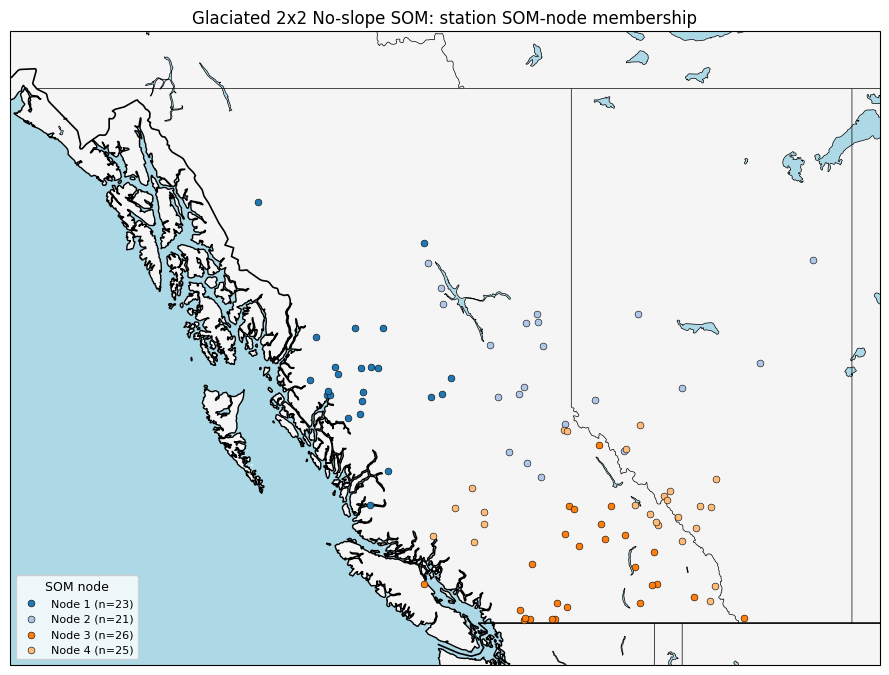

Glaciated 2x2 No-slope SOM: stations per node by glaciation


glac_class,Low (<1%),Medium (1–5%),High (>5%),glaciated,non_glaciated,total
node,,,,,,
1,12,6,5,23,0,23
2,14,7,0,21,0,21
3,12,12,2,26,0,26
4,6,9,10,25,0,25


Glaciated 3x4 node sizes: [9, 10, 1, 17, 10, 3, 1, 8, 14, 6, 9, 7]


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


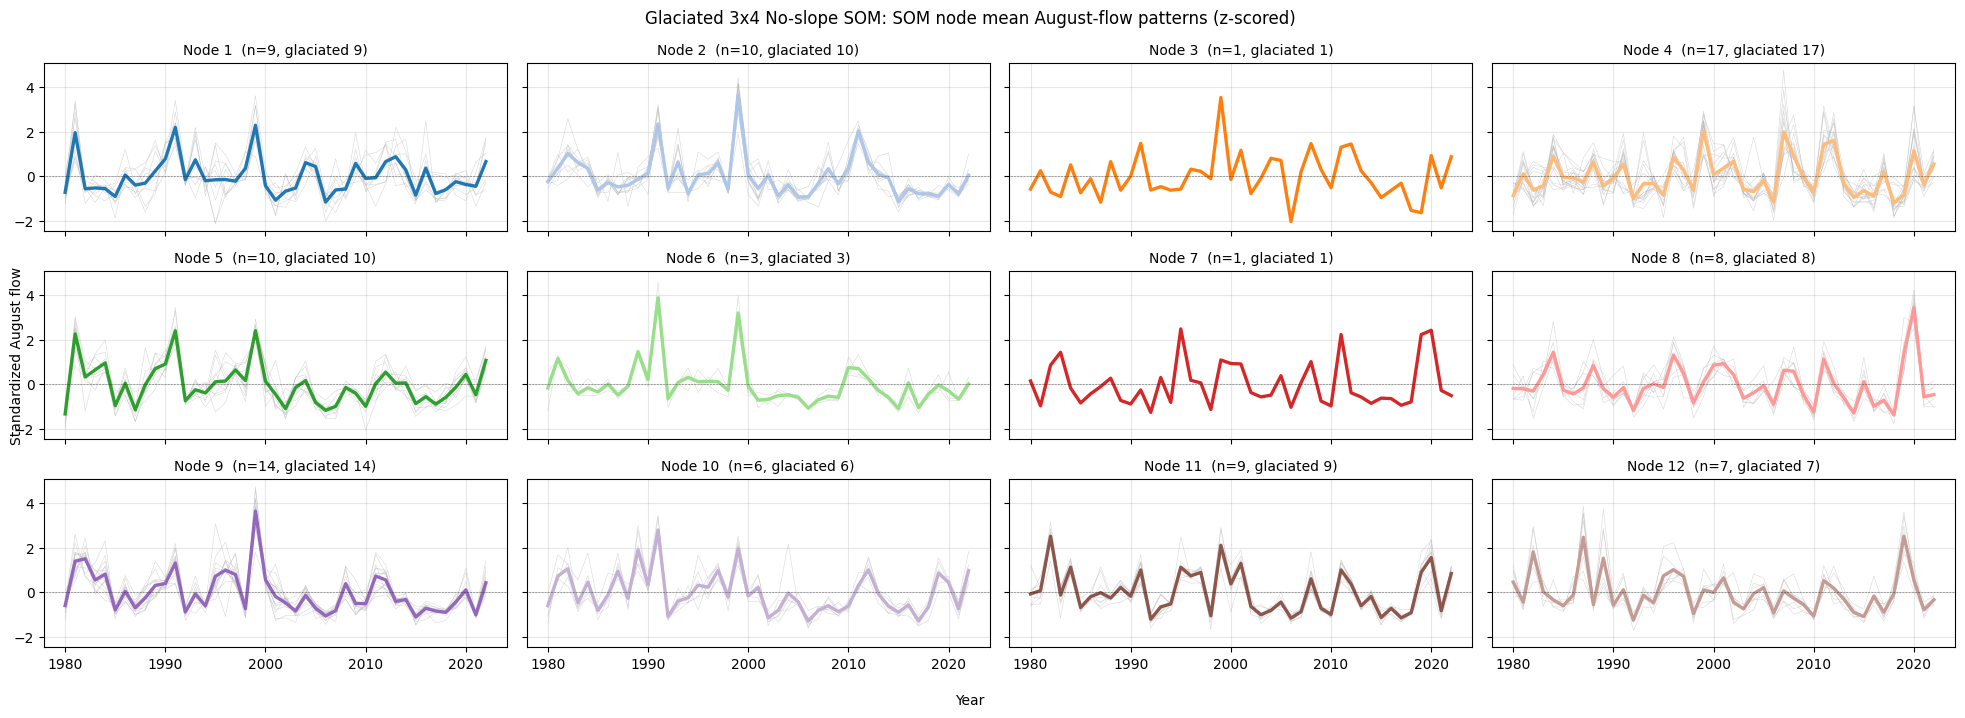

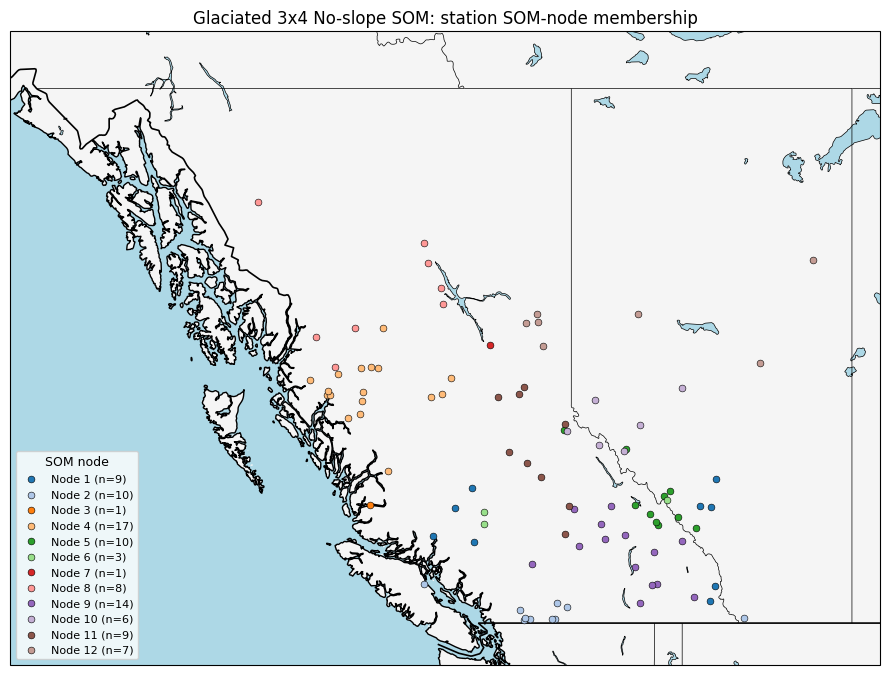

Glaciated 3x4 No-slope SOM: stations per node by glaciation


glac_class,Low (<1%),Medium (1–5%),High (>5%),glaciated,non_glaciated,total
node,,,,,,
1,4,2,3,9,0,9
2,6,3,1,10,0,10
3,0,0,1,1,0,1
4,7,6,4,17,0,17
5,0,4,6,10,0,10
6,1,2,0,3,0,3
7,1,0,0,1,0,1
8,8,0,0,8,0,8
9,7,6,1,14,0,14



===== Non-glaciated: n=174 stations =====
Non-glaciated 2x2 node sizes: [53, 46, 32, 43]


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


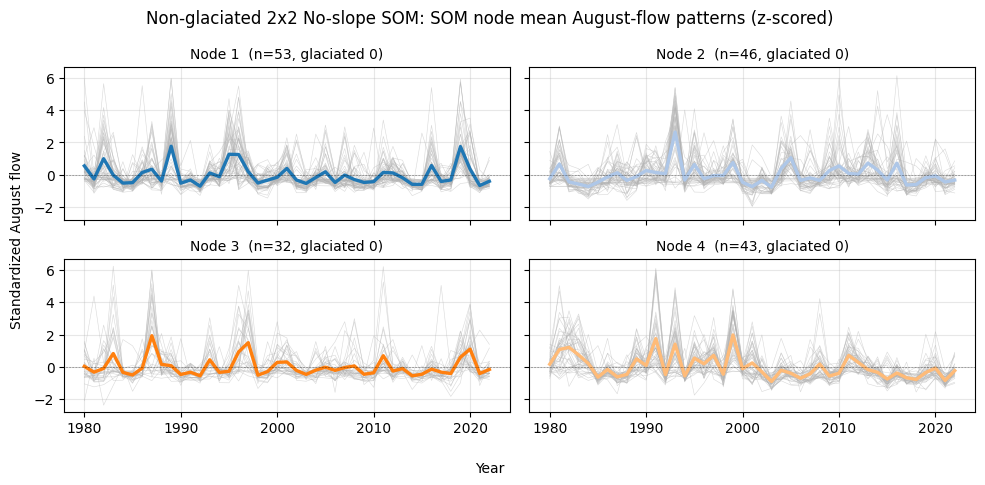

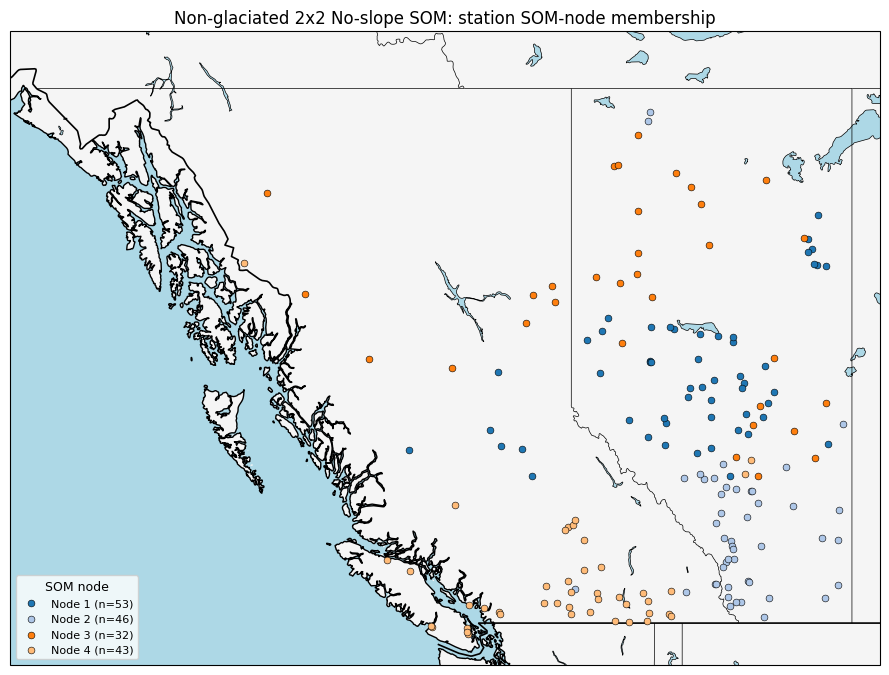

Non-glaciated 2x2 No-slope SOM: stations per node by glaciation


glac_class,Non-glaciated,glaciated,non_glaciated,total
node,,,,
1,53,0,53,53
2,46,0,46,46
3,32,0,32,32
4,43,0,43,43


Non-glaciated 3x4 node sizes: [17, 12, 12, 23, 17, 7, 13, 7, 20, 15, 13, 18]


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: divide by zero encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: overflow encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_6725/843917462.py:22: RuntimeWarning: invalid value encountered in matmul
  W = (h.T @ X) / h.sum(0)[:, None]


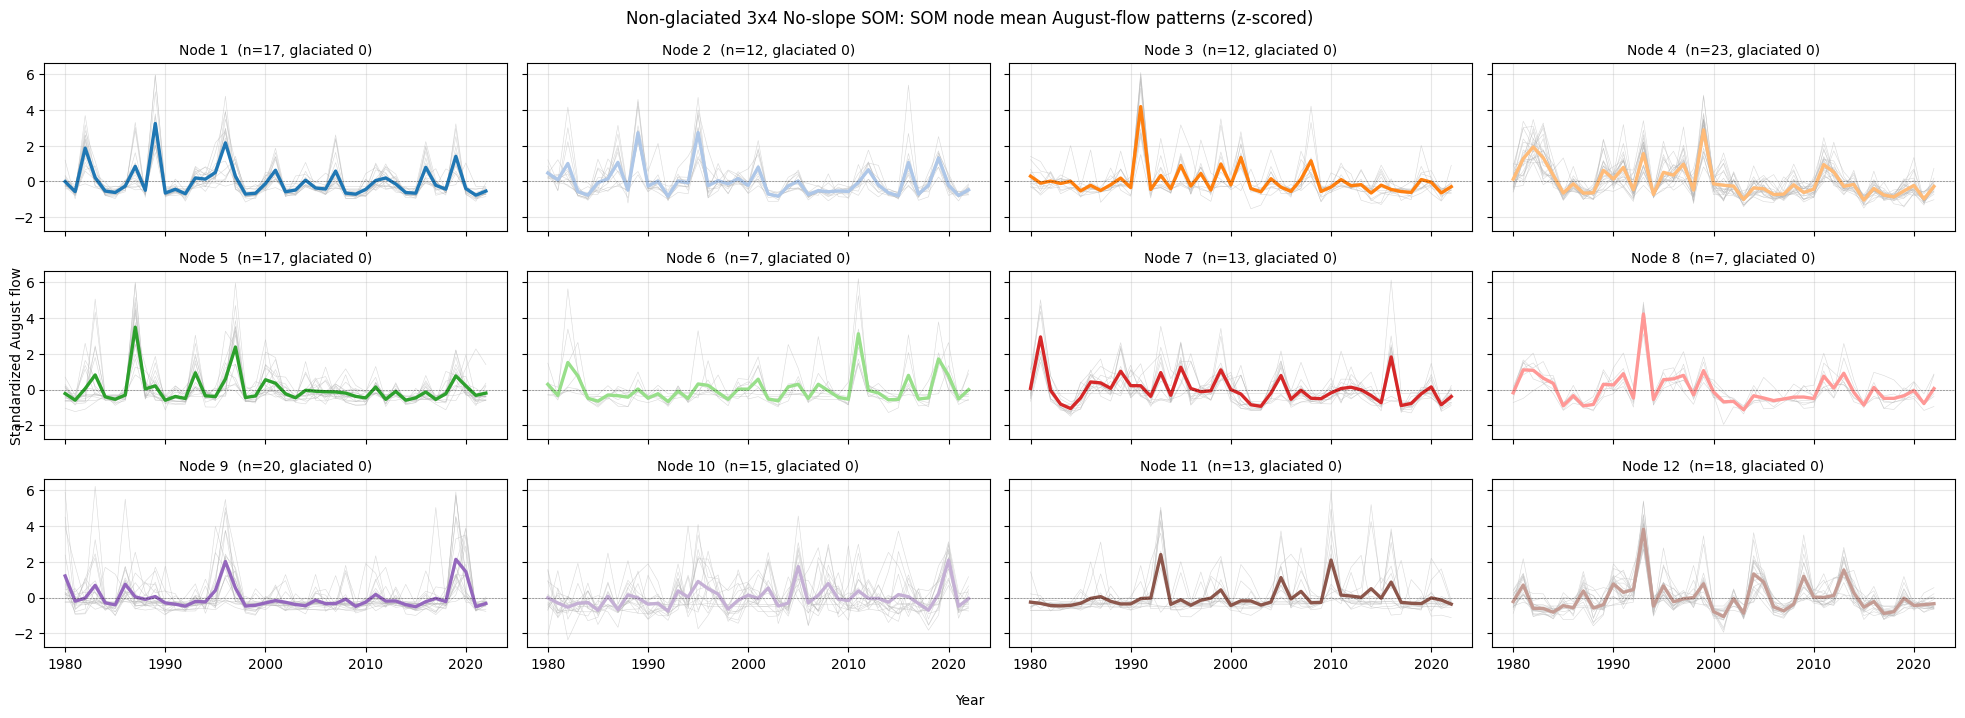

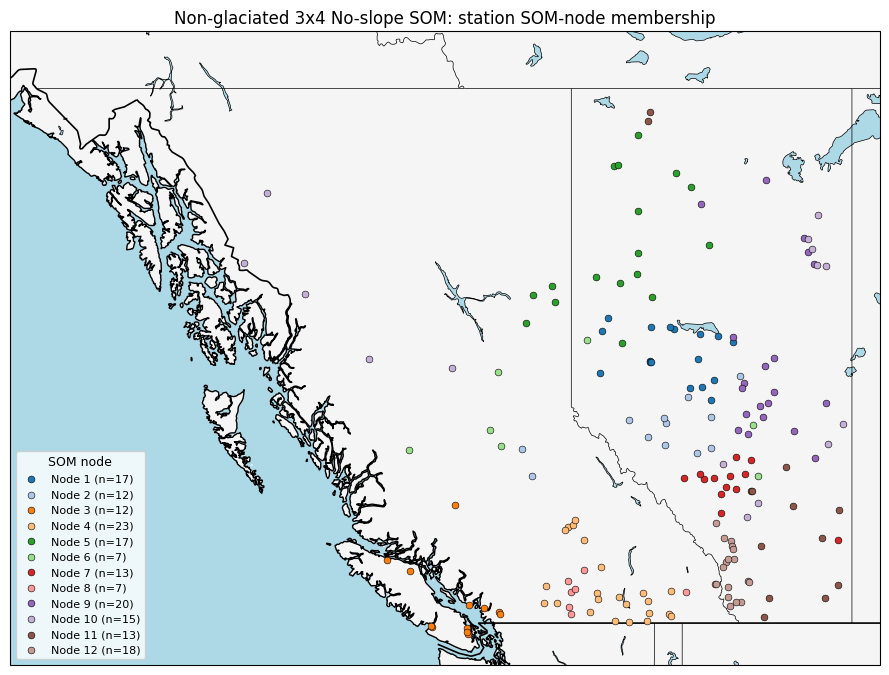

Non-glaciated 3x4 No-slope SOM: stations per node by glaciation


glac_class,Non-glaciated,glaciated,non_glaciated,total
node,,,,
1,17,0,17,17
2,12,0,12,12
3,12,0,12,12
4,23,0,23,23
5,17,0,17,17
6,7,0,7,7
7,13,0,13,13
8,7,0,7,7
9,20,0,20,20


In [43]:
# Cell 13: Step 4 — SOMs separated by glaciation (glaciated vs non-glaciated)
# Per Valentina's Step 4: train the SOM independently on each subgroup to surface the
# characteristic August streamflow shapes WITHIN each group. Separation reuses the earlier
# df_stn['glaciated'] = glacier_pct > 0 flag. Per-station z-scores are self-contained, so
# subsetting rows of X_shape needs no renormalization. Grids: 2x2 and 3x4 (matching Step 3).

SUBGROUP_GRIDS = [(2, 2), (3, 4)]
PALETTE_12 = [plt.cm.tab20(i) for i in range(12)]

# Boolean mask aligned to the `stns` / X_shape row order
glac_mask = df_stn.loc[stns, 'glaciated'].to_numpy()
print(f"Glaciation split (glacier_pct > 0): "
      f"glaciated n={int(glac_mask.sum())}, "
      f"non-glaciated n={int((~glac_mask).sum())}, "
      f"total n={len(stns)}")

def run_subgroup_som(name, mask):
    """Train + plot the SOM on a station subset, reusing the global plot_som_grid().
    Temporarily rebinds the globals plot_som_grid() reads (X_shape, stns), then restores."""
    global X_shape, stns
    X_full, stns_full = X_shape, stns
    try:
        X_shape, stns = X_full[mask], stns_full[mask]
        print(f"\n===== {name}: n={len(stns)} stations =====")
        for grid in SUBGROUP_GRIDS:
            n_nodes = grid[0] * grid[1]
            _, bmu, _ = train_som(X_shape, grid=grid)
            print(f"{name} {grid[0]}x{grid[1]} node sizes: "
                  f"{np.bincount(bmu, minlength=n_nodes).tolist()}")
            plot_som_grid(f"{name} {grid[0]}x{grid[1]} No-slope SOM",
                          bmu, grid, PALETTE_12[:n_nodes])
    finally:
        X_shape, stns = X_full, stns_full

run_subgroup_som('Glaciated', glac_mask)
run_subgroup_som('Non-glaciated', ~glac_mask)

<a id="moving-variance"></a>
## 7. Moving Variance of August Flow (observed)

Centered rolling variance of each basin's August mean flow — **observed only** (the obs-only port of the EXP4b variance pipeline; no sim/ensemble, no inference). Windows: **10, 15, 20** years.

Flow is converted m³/s → mm/day (`factor = 86.4 / basin_area_km2`) so variance is area-normalized and comparable across basins for the population view.

Visual inspection is the deliverable:
- **Population-mean** rolling variance over time at the three windows, and split glaciated vs non-glaciated (primary 15-yr window).
- **Per-station** variance trajectories (15-yr), grouped by glaciation class.

10-yr window: 34 window-centers (1985–2018) x 269 basins
15-yr window: 29 window-centers (1987–2015) x 269 basins
20-yr window: 24 window-centers (1990–2013) x 268 basins


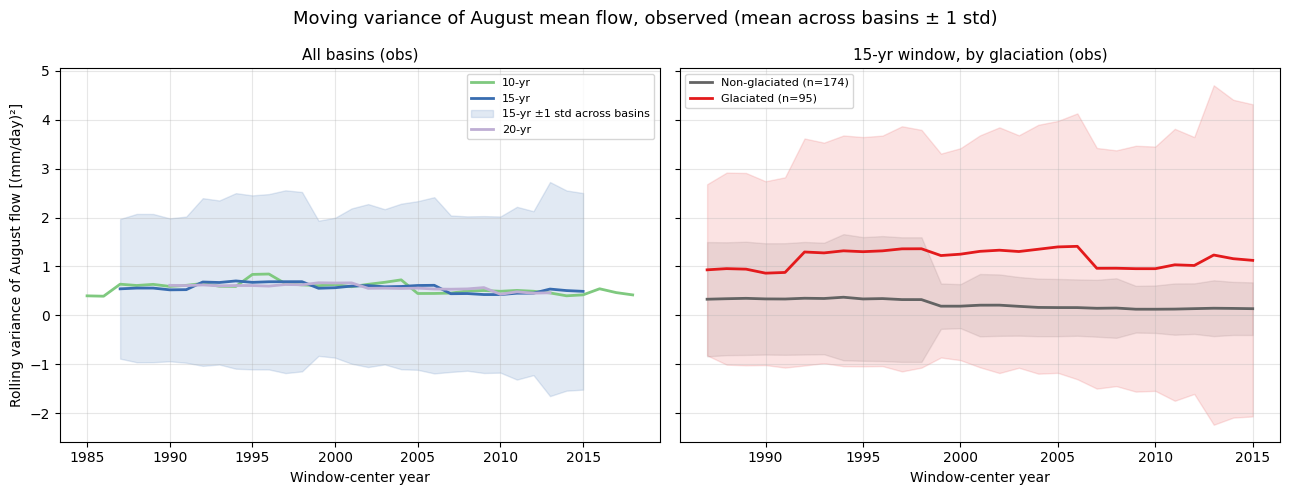

In [41]:
# Cell 14: Moving variance (obs only) — convert to mm/day, rolling var at 10/15/20
WINDOWS_VAR = [10, 15, 20]
PRIMARY_W = 15

# m3/s -> mm/day (area-normalized), per the 2026-05-19 methods decision
area_km2 = df_stn.loc[aug_flow.columns, 'basin_area_km2']
aug_mmday = aug_flow.mul(86.4 / area_km2, axis=1)

def rolling_var(df, window):
    """Centered rolling variance per basin; NaN where the window isn't fully covered."""
    return df.rolling(window, center=True, min_periods=window).var()

rvar_by_w = {w: rolling_var(aug_mmday, w).dropna(how='all') for w in WINDOWS_VAR}

for w in WINDOWS_VAR:
    rv = rvar_by_w[w]
    print(f"{w:>2}-yr window: {rv.shape[0]:>2} window-centers "
          f"({int(rv.index.min())}–{int(rv.index.max())}) x {int(rv.notna().any().sum())} basins")

# --- Figure: population-mean rolling variance over time ---
# Left: all basins, one curve per window (+/-1 std band on the primary window).
# Right: primary window, split glaciated vs non-glaciated.
glac_col = df_stn.loc[aug_mmday.columns, 'glaciated']
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

win_colors = {10: '#7fc97f', 15: '#386cb0', 20: '#beaed4'}
for w in WINDOWS_VAR:
    rv = rvar_by_w[w]
    pop = rv.mean(axis=1)
    axL.plot(pop.index, pop.values, color=win_colors[w], lw=2, label=f'{w}-yr')
    if w == PRIMARY_W:
        sd = rv.std(axis=1)
        axL.fill_between(pop.index, pop - sd, pop + sd, color=win_colors[w], alpha=0.15,
                         label=f'{w}-yr ±1 std across basins')
axL.set_title('All basins (obs)', fontsize=11)
axL.set_xlabel('Window-center year')
axL.set_ylabel('Rolling variance of August flow [(mm/day)²]')
axL.legend(fontsize=8); axL.grid(alpha=0.3)

rvP = rvar_by_w[PRIMARY_W]
for is_glac, lab, col in [(False, 'Non-glaciated', '#636363'), (True, 'Glaciated', '#e31a1c')]:
    cols = glac_col.index[glac_col.to_numpy() == is_glac]
    sub = rvP[cols]
    m = sub.mean(axis=1)
    axR.plot(m.index, m.values, color=col, lw=2, label=f'{lab} (n={len(cols)})')
    axR.fill_between(m.index, m - sub.std(axis=1), m + sub.std(axis=1), color=col, alpha=0.12)
axR.set_title(f'{PRIMARY_W}-yr window, by glaciation (obs)', fontsize=11)
axR.set_xlabel('Window-center year'); axR.legend(fontsize=8); axR.grid(alpha=0.3)

fig.suptitle('Moving variance of August mean flow, observed (mean across basins ± 1 std)', fontsize=13)
plt.tight_layout()
plt.show()

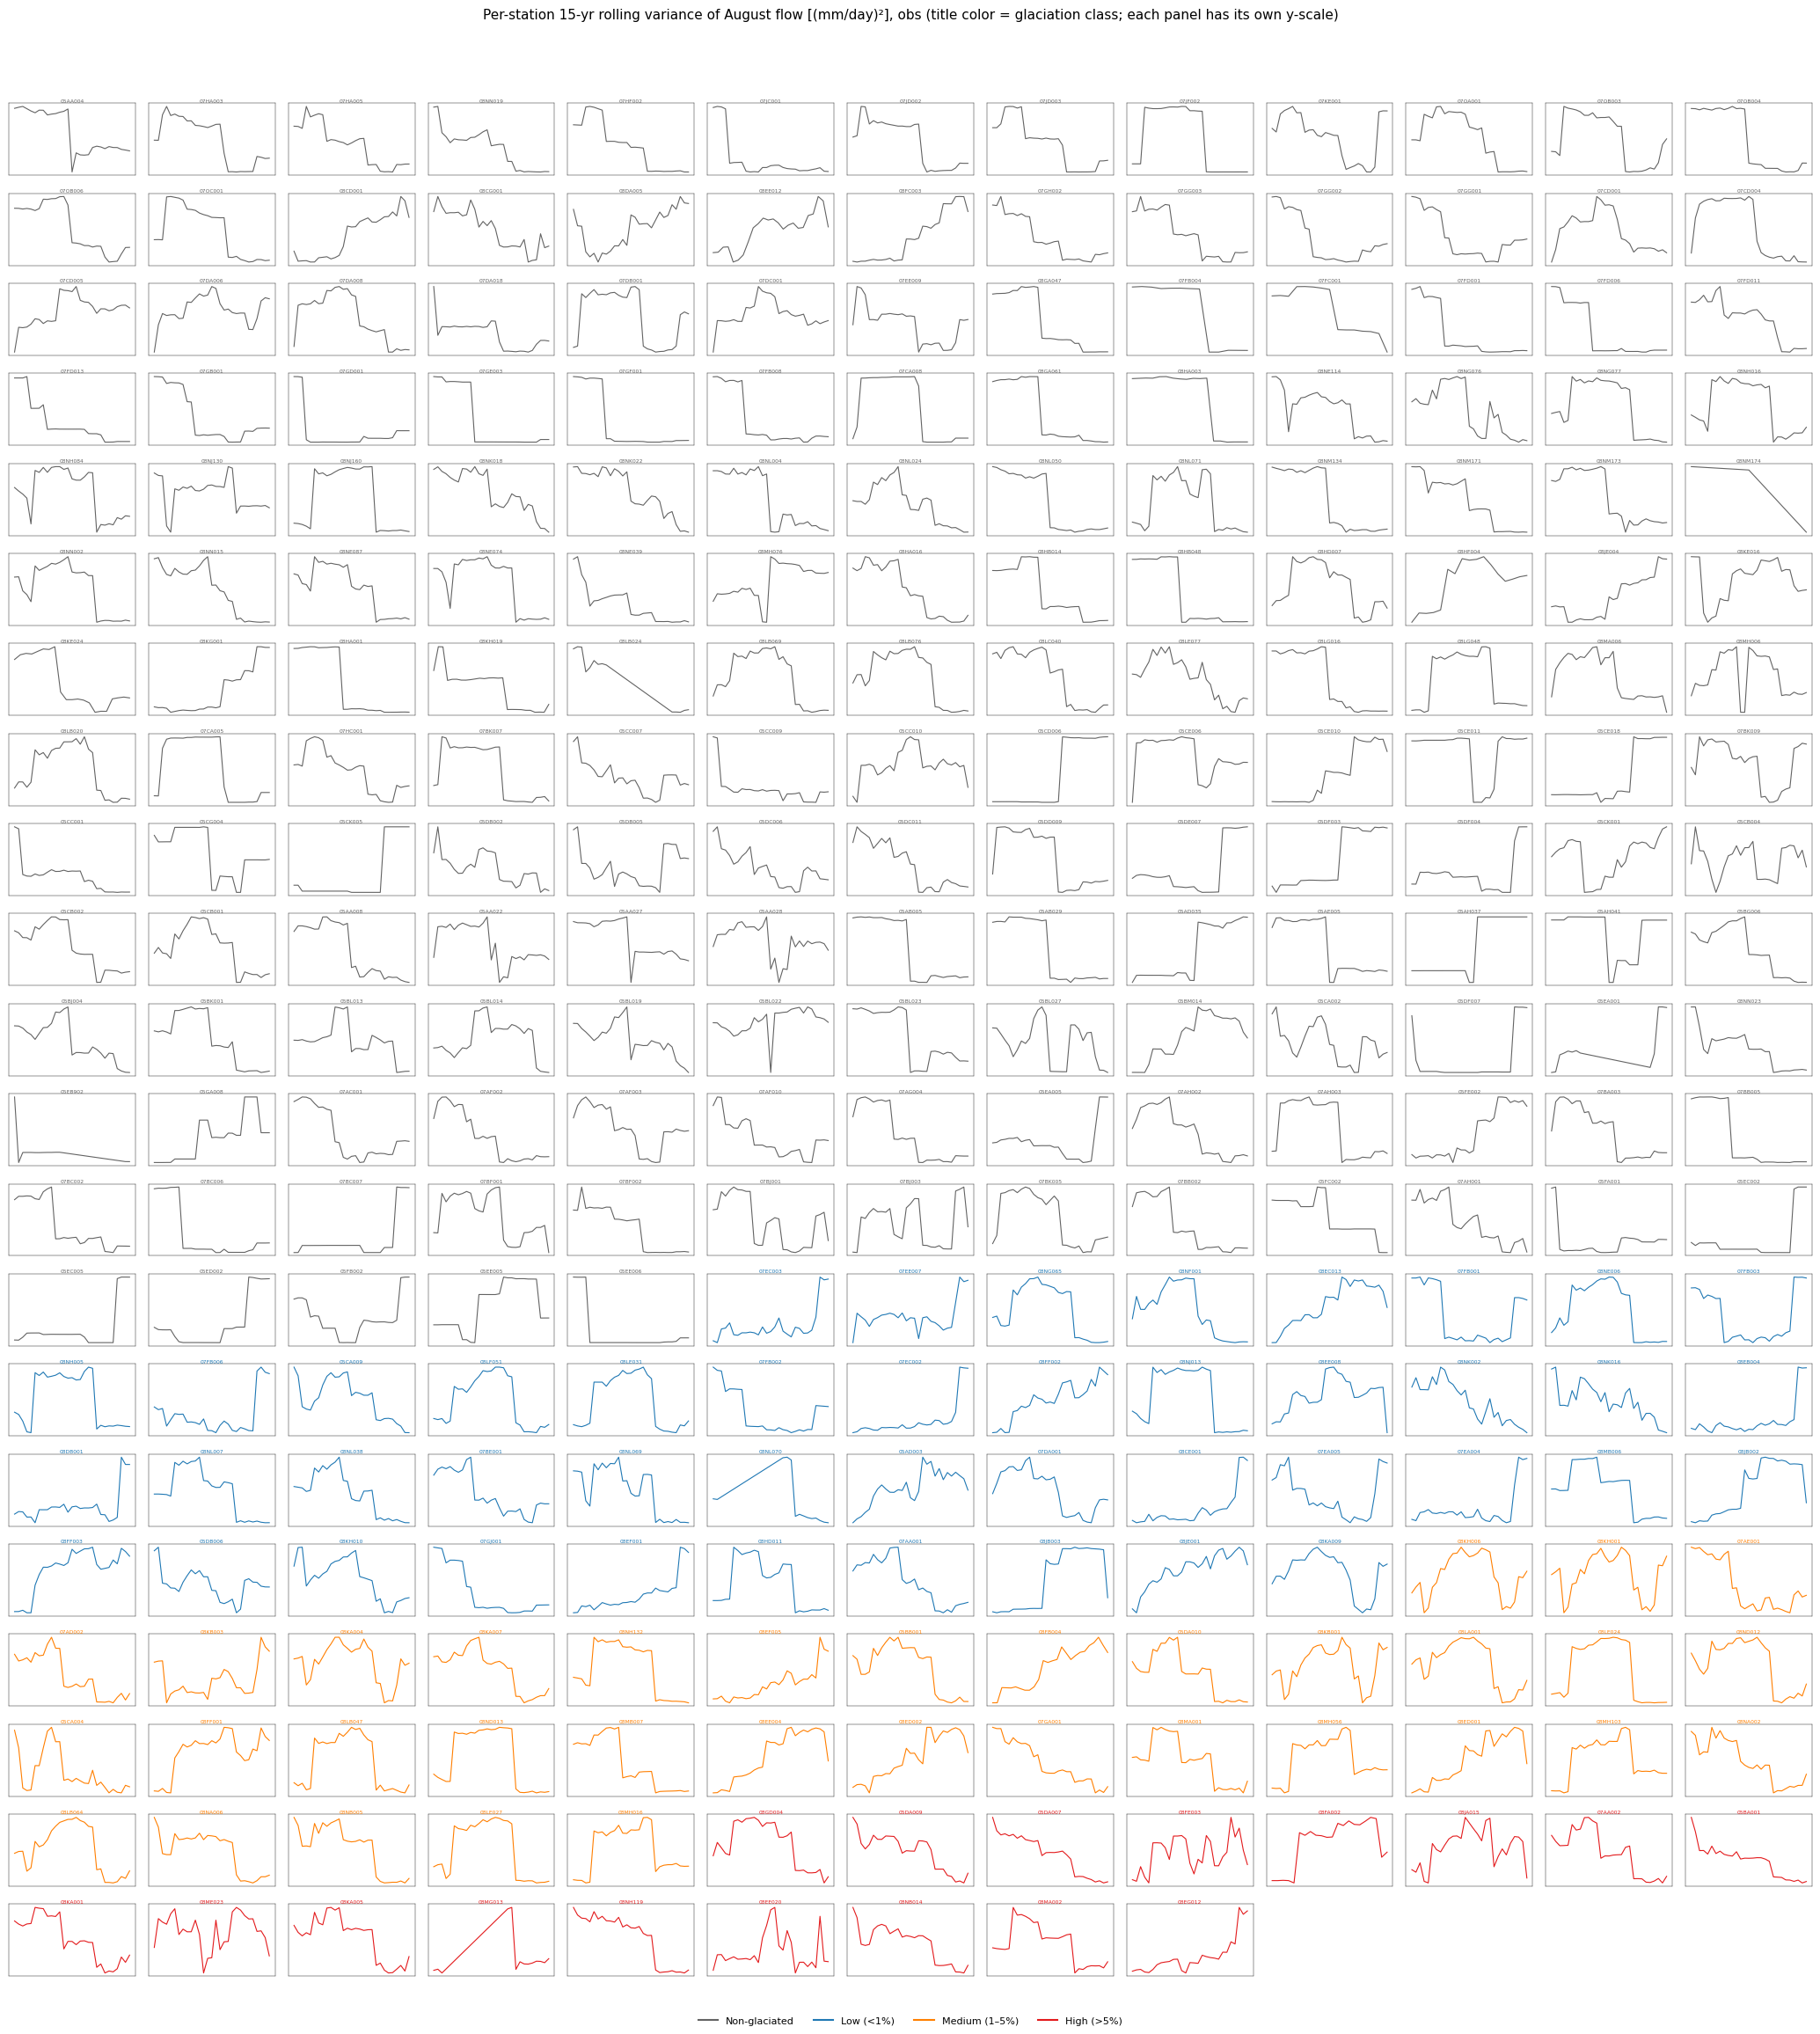

In [42]:
# Cell 15: Per-station rolling-variance trajectories (primary 15-yr window), by glaciation
# One panel per station, own y-scale (within-station shape, not cross-basin magnitude).
var_class_color = {
    'Non-glaciated': '#636363', 'Low (<1%)': '#1f78b4',
    'Medium (1–5%)': '#ff7f00', 'High (>5%)': '#e31a1c',
}
rvP = rvar_by_w[PRIMARY_W]
order = df_stn.loc[rvP.columns].sort_values('glac_class').index

ncols = 13
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 1.1))
axes = axes.flatten()
for ax, stn in zip(axes, order):
    s = rvP[stn].dropna()
    cls = str(df_stn.at[stn, 'glac_class'])
    if len(s):
        ax.plot(s.index, s.values, color=var_class_color[cls], lw=0.8)
    ax.set_title(stn, fontsize=4.3, pad=1, color=var_class_color[cls])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.3)
for ax in axes[len(order):]:
    ax.axis('off')

class_handles = [mlines.Line2D([], [], color=c, lw=1.5, label=l)
                 for l, c in var_class_color.items()]
fig.suptitle(f'Per-station {PRIMARY_W}-yr rolling variance of August flow [(mm/day)²], obs '
             '(title color = glaciation class; each panel has its own y-scale)',
             fontsize=11, y=0.995)
fig.legend(handles=class_handles, loc='lower center', ncol=4, fontsize=8, frameon=False)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

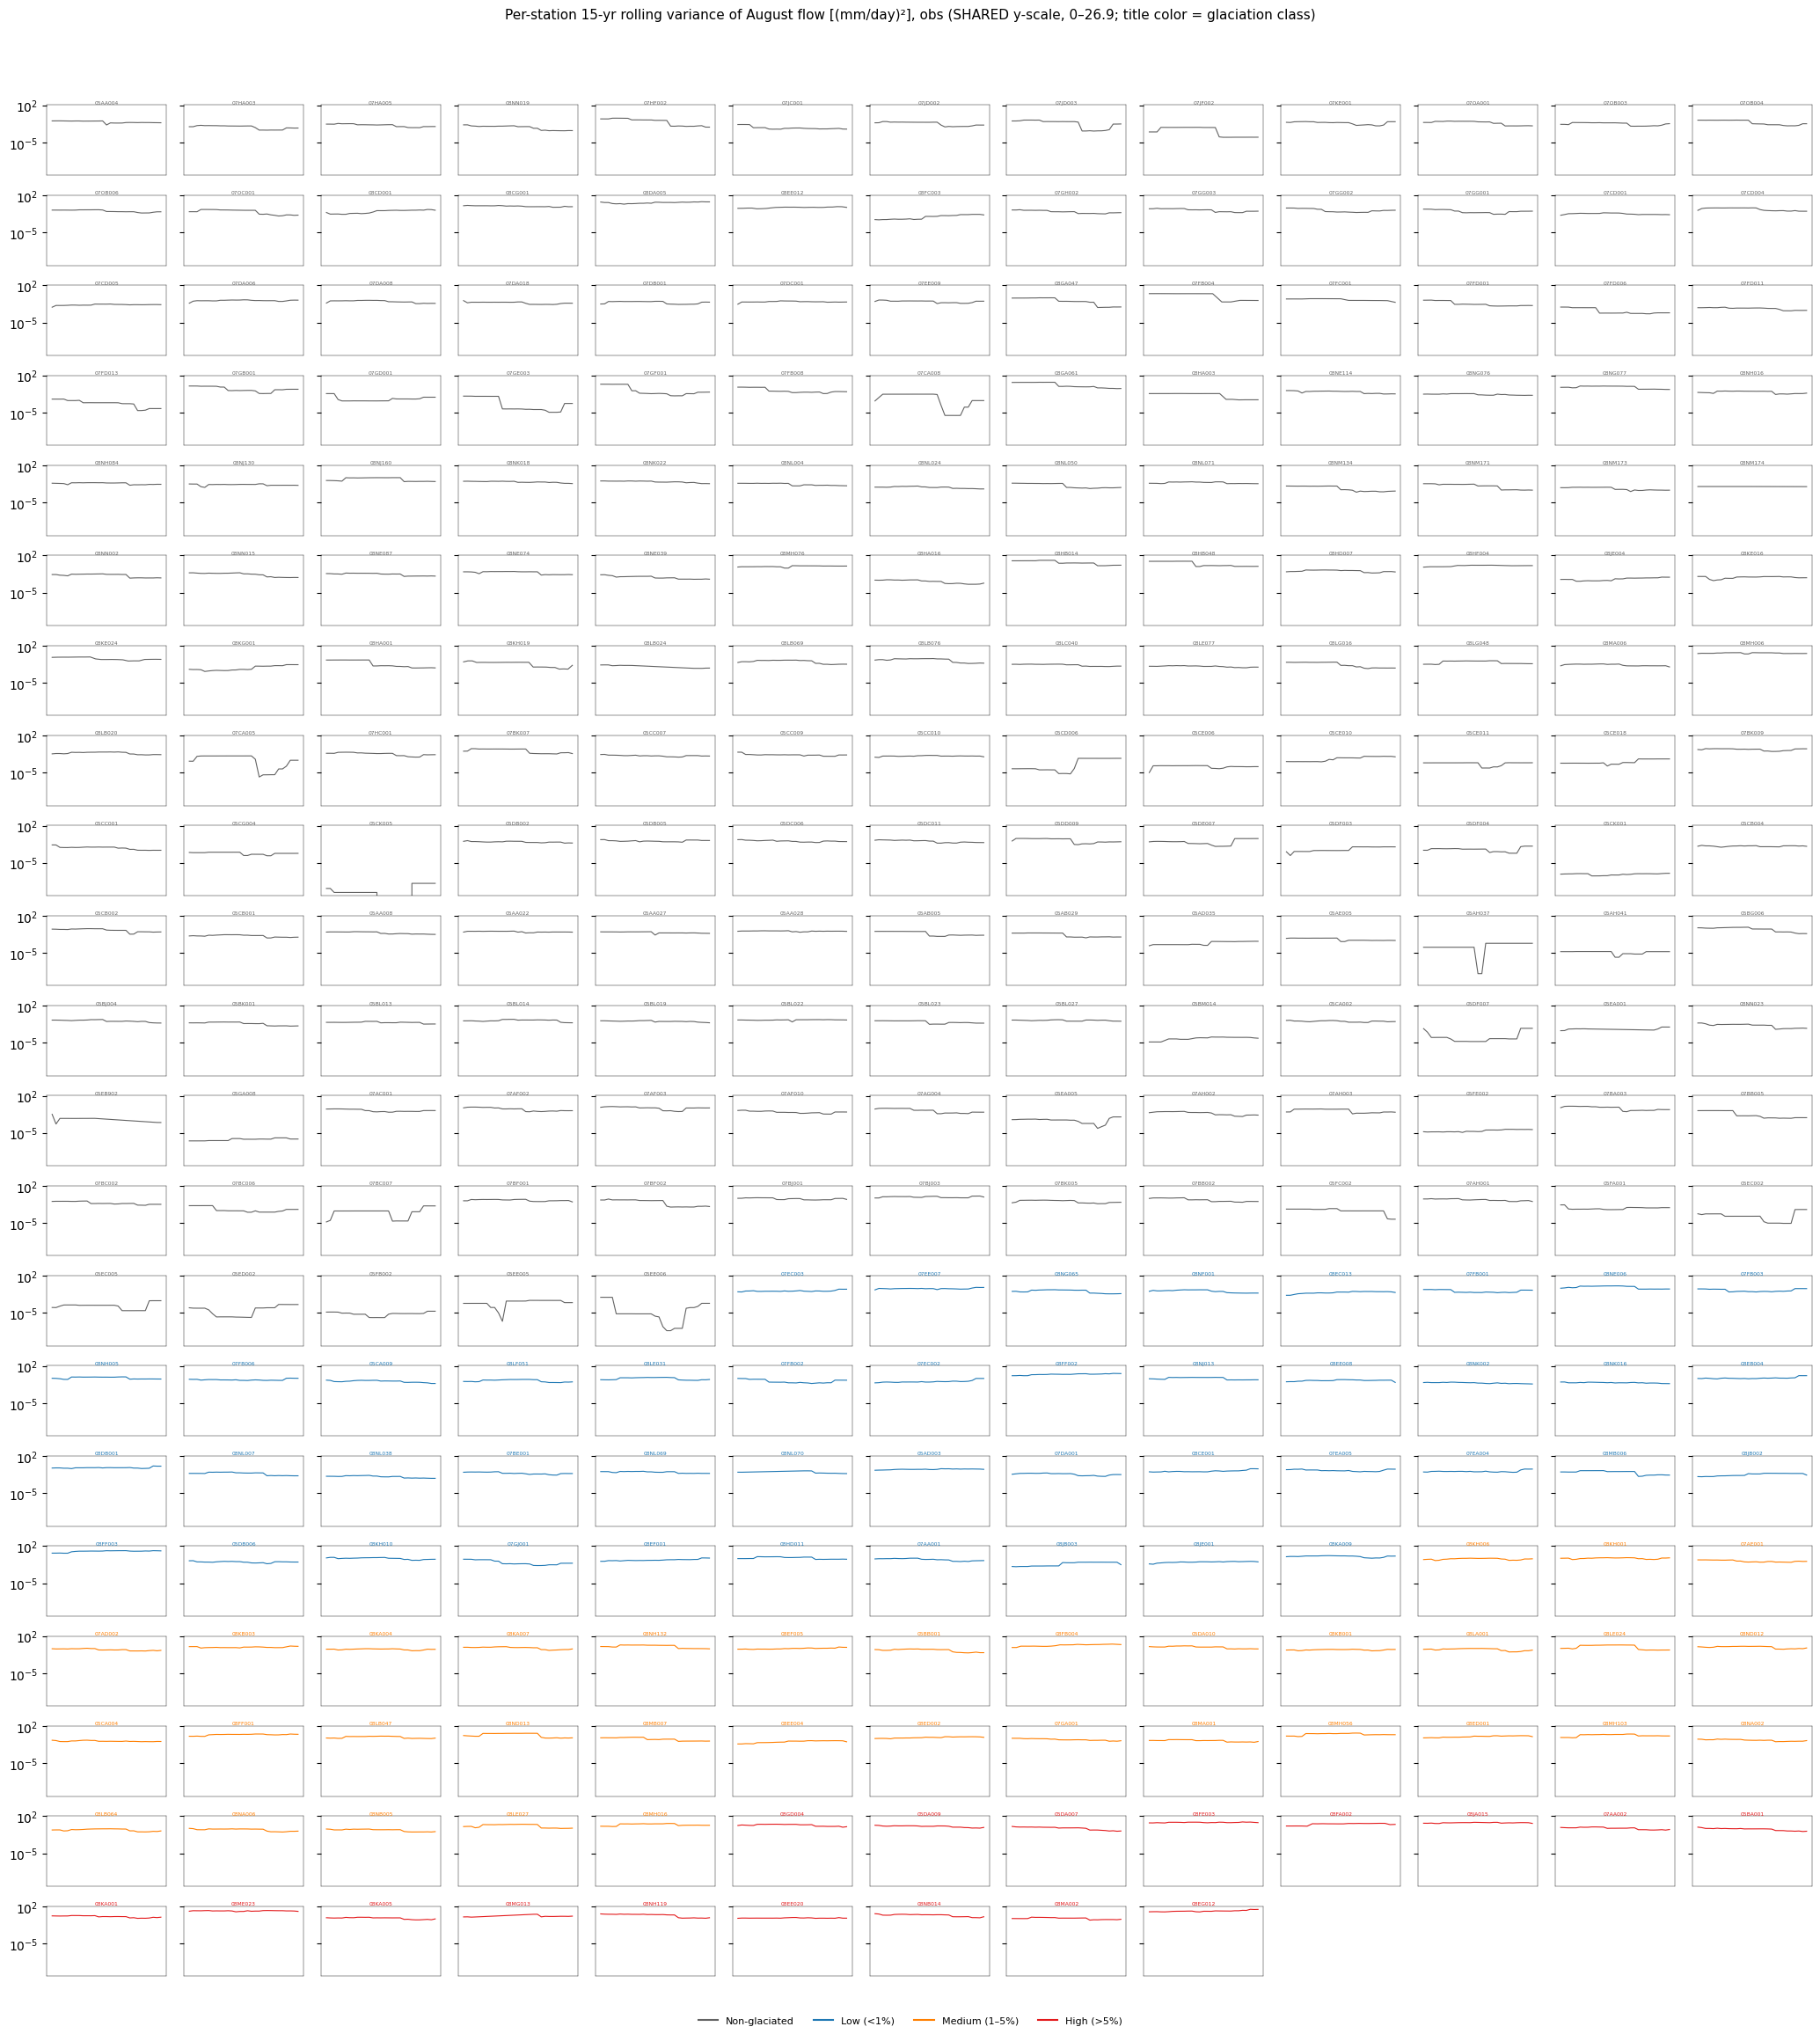

In [46]:
# Cell 16: Per-station rolling variance — SHARED y-scale (magnitude-comparable, mm/day)
# Same data/order as Cell 15, but every panel uses one common y-axis so panel height
# means absolute variance. Expect high-variance (often flashy, low-elevation) basins to
# set the ceiling and most basins to read as near-flat low lines — that contrast is the point.
rvP = rvar_by_w[PRIMARY_W]
order = df_stn.loc[rvP.columns].sort_values('glac_class').index

ncols = 13
nrows = int(np.ceil(len(order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 1.1), sharey=True)
axes = axes.flatten()
for ax, stn in zip(axes, order):
    s = rvP[stn].dropna()
    cls = str(df_stn.at[stn, 'glac_class'])
    if len(s):
        ax.plot(s.index, s.values, color=var_class_color[cls], lw=0.8)
    ax.set_title(stn, fontsize=4.3, pad=1, color=var_class_color[cls])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.3)
for ax in axes[len(order):]:
    ax.axis('off')
    ax.set_yscale('log')

class_handles = [mlines.Line2D([], [], color=c, lw=1.5, label=l)
                 for l, c in var_class_color.items()]
ymax = float(rvP.max().max())
fig.suptitle(f'Per-station {PRIMARY_W}-yr rolling variance of August flow [(mm/day)²], obs '
             f'(SHARED y-scale, 0–{ymax:.1f}; title color = glaciation class)',
             fontsize=11, y=0.995)
fig.legend(handles=class_handles, loc='lower center', ncol=4, fontsize=8, frameon=False)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()


<a id="som"></a>
## 8. Inference Between Groups

We need to conduct inference in two ways:

1. Differentiable Trends between Groups (Glacier-Fed (n=105), and Not (n=169)) - Visual from SOMs
2. In glacier-fed rivers, do we see signals in the observed time series that support the hypothesis of glacier area changes over these 42 years? This should be visible via Means or Moving Variance